In [1]:
from ioMicro import *

## Load data

In [2]:
data_folder= '/oasis/tscc/scratch/zgibbs/10_12_2023__CRE-20_RNASEQ/'

In [3]:
# map all the hybes
hybes =  glob.glob(data_folder+os.sep+'H*')
# map all the fovs
fovs = [os.path.basename(fl)for fl in glob.glob(hybes[0]+os.sep+'*.zarr')]
def get_Hi(fld): 
    try: return int(os.path.basename(fld)[1:]) 
    except: return -1
    
hybes = np.array(hybes)[np.argsort([get_Hi(hybe) for hybe in hybes ])]

In [4]:
fovs.sort()

In [5]:
def get_two_GFP_sets(fl,hmin_fit=750,hcutoff=3000,cor_good=0.5,cor_bad=0.25,
                     dist_cutoff_good=4,dist_cutoff_bad=20,plt_val=False):
    im = read_im(fl)
    imGFP1 = np.array(im[0],dtype=np.float32) #GFP 750 half
    imGFP2 = np.array(im[1],dtype=np.float32) #GFP cy5 half
    #Subtract local background
    imGFP1_ = norm_slice(imGFP1, s=30)
    imGFP2_ = norm_slice(imGFP2, s=30)
    #fit both GFPs
    Xh1 = get_local_max(imGFP1_,hmin_fit,im_raw=imGFP1,delta=1,delta_fit=3)
    Xh2 = get_local_max(imGFP2_,hmin_fit,im_raw=imGFP2,delta=1,delta_fit=3)
    #zc-center positions in pixels for z,xc,yc,bk- minimum signal within radius,a-total sum of signal within sphere of radius 3 pixels ,habs - max brightness of local max in oridgianl image,hn - correlation with expected PSF,h- maxium brightness in the subtracted


    hcutoff = hcutoff
    #threshold points based on brightness (h) and correlation with PSF
    h = Xh1[:,-1]
    cor = Xh1[:,-2]
    keep = (h>hcutoff)&(cor>cor_good)
    h = Xh1[keep,-1]
    X = Xh1[keep,:3]
    X1 = X
    
    h = Xh2[:,-1]
    cor = Xh2[:,-2]
    keep = (h>hcutoff)&(cor>cor_good)
    h = Xh2[keep,-1]
    X = Xh2[keep,:3]
    X2 = X
    
    
    # find the bad points (junk) and exlcude points next to them
    h = Xh1[:,-1]
    cor = Xh1[:,-2]
    keep = (h>hcutoff)&(cor<cor_bad)
    Xbad = Xh1[keep,:3]
    h = Xh2[:,-1]
    cor = Xh2[:,-2]
    keep = (h>hcutoff)&(cor<cor_bad)
    Xbad = np.concatenate([Xbad,Xh2[keep,:3]],axis=0)
    
    from scipy.spatial import KDTree
    tree1 = KDTree(X1)
    dist,ind1 = tree1.query(X2)
    ind2 = np.arange(len(X2))
    keep = dist<dist_cutoff_good
    ind1,ind2=ind1[keep],ind2[keep]
    X1_,X2_ = X1[ind1],X2[ind2]
    #exclude bad points
    tree_bad = KDTree(Xbad)
    d1,ind1=tree_bad.query(X1_)
    d2,ind2=tree_bad.query(X2_)
    X1f = X1_[d1>dist_cutoff_bad]
    X2f = X2_[d1>dist_cutoff_bad]
    if plt_val:
        import napari
        v = napari.Viewer()
        v.add_image(imGFP1_,colormap='green',blending='additive',contrast_limits=[0,10000])
        v.add_image(imGFP2_,colormap='red',blending='additive',contrast_limits=[0,10000])
        v.add_points(X1f,face_color='g',blending='additive')
        v.add_points(X2f,face_color='r',blending='additive')
    return X1f,X2f

## Fit spots for YFP and perform chromatic abberation correction

In [9]:
hybes[8]

'/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H9'

In [10]:
# Fit YFP spots for A750 and Cy5 channels for all FOVs in dataset and save results

analysis_folder = '/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ'
if not os.path.exists(analysis_folder): os.makedirs(analysis_folder)
for fov in tqdm(fovs):
    fl = hybes[8]+os.sep+fov # choose which hybe here represents YFP imaging
    save_fl = analysis_folder+os.sep+fov.split('.')[0]+'_GFP2X.pkl'
    if not os.path.exists(save_fl):
        X1f,X2f = get_two_GFP_sets(fl,hmin_fit=750,hcutoff=2500,cor_good=0.5,cor_bad=0.25,
                             dist_cutoff_good=4,dist_cutoff_bad=20,plt_val=False)
        np.save(save_fl,[X1f,X2f])

100%|██████████| 134/134 [1:56:46<00:00, 52.29s/it] 


In [11]:
# Load the fit YFP spots for all FOVs into a single array to correct the chromatic aberration

analysis_folder = '/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ'
X1fs,X2fs = [],[]
for fov in tqdm(fovs):
    save_fl = analysis_folder+os.sep+fov.split('.')[0]+'_GFP2X.pkl.npy'
    X1f,X2f = np.load(save_fl)
    X1fs.extend(X1f)
    X2fs.extend(X2f)
    
X1fs = np.array(X1fs)
X2fs = np.array(X2fs)

100%|██████████| 134/134 [00:00<00:00, 255.10it/s]


Text(0.5, 1.0, 'Chromatic aberration')

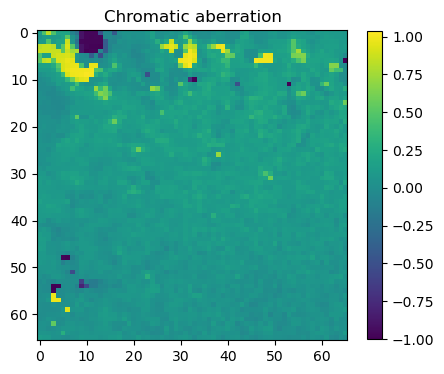

In [12]:
# Calculate the pixel drift between A750 and Cy5 YFP spots (chromatic aberration; imT) using a KDTree analysis

sx,sy = 2000,2000 # size of images in pixels
resc = 30 # scaling factor to apply to image
Xim = np.indices([sx//resc,sy//resc]).reshape([2,-1]).T*resc

from scipy.spatial import KDTree
tree = KDTree(X1fs[:,1:])
dneigh,ineigh = tree.query(Xim,k=50)
dif = X2fs-X1fs # measure distance between A750 and Cy5 spots determined with the get_local_max function above
dM = dif[ineigh]
ddist = 200
dM[dneigh>ddist]=np.nan
ddif = np.nanmedian(dM,axis=1)
imT =ddif.reshape([sx//resc,sy//resc,3])[:,:,1]

fig, ax = plt.subplots(figsize=(5, 5))
plt.imshow(imT)
plt.colorbar(shrink=0.8)
plt.title('Chromatic aberration')
# ax.tick_params(length=0)
# ax.xaxis.set_tick_params(labelbottom=False)
# ax.yaxis.set_tick_params(labelleft=False)

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/analysis/KDtree_1', bbox_inches='tight', dpi=300) 

In [10]:
def calc_color_matrix(x,yd,order=2):
    """This gives a quadratic color transformation (in matrix form)
    x is Nx3 vector of positions in the reference channel (typically cy5)
    yd is the Nx3 vector of positions in another channel - the reference (i.e. cy7-cy5)
    return m_ a 3x7 matrix which when multipled with x,x**2,1 returns y-x
    This m_ is indended to be used with apply_colorcor
    """ 
    x_ = np.array(x)# ref zxy
    y_ = np.array(yd)# dif zxy
    good = ~np.any(np.isnan(y_),axis=-1)
    x_ = x_[good]
    y_ = y_[good]
    
    # get a list of exponents
    exps = []
    for p in range(order+1):
        for i in range(p+1):
            for j in range(p+1):
                if i+j<=p:
                    exps.append([i,j,p-i-j])
    # construct A matrix
    A = np.zeros([len(x_),len(exps)])
    for iA,(ix,iy,iz) in enumerate(exps):
        s = (x_[:,0]**ix*x_[:,1]**iy*x_[:,2]**iz)
        A[:,iA]=s
    m_ = [np.linalg.lstsq(A, y_[:,iy])[0] for iy in range(len(x_[0]))]
    m_=np.array(m_)
    return m_
def apply_colorcor(x,m=None):
    """This applies chromatic abberation correction to order 2
    x is a Nx3 vector of positions (typically 750(-->647))
    m is a matrix computed by function calc_color_matrix
    y is the corrected vector in another channel"""
    if m is None:
        return x
    exps = []
    order_max=10
    for p in range(order_max+1):
        for i in range(p+1):
            for j in range(p+1):
                if i+j<=p:
                    exps.append([i,j,p-i-j])
    #find the order
    mx,my = m.shape
    order = int((my-1)/mx)
    assert(my<len(exps))
    x_ = np.array(x)
    # construct A matrix
    exps = exps[:my]
    A = np.zeros([len(x_),len(exps)])
    for iA,(ix,iy,iz) in enumerate(exps):
        s = (x_[:,0]**ix*x_[:,1]**iy*x_[:,2]**iz)
        A[:,iA]=s
    diff = [np.dot(A,m_) for m_ in m]
    return x_+np.array(diff).T

In [14]:
# Calculate the chromatic correction matrix (m) 

Xim_ = Xim[:,[0,0,1]]
Xim_[:,0]=0
m = calc_color_matrix(Xim_,ddif,order=1)

/scratch/zgibbs/33066630.tscc-mgr7.local/ipykernel_111451/4078241219.py:26: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  m_ = [np.linalg.lstsq(A, y_[:,iy])[0] for iy in range(len(x_[0]))]


In [16]:
# Save the new chromatic correction matrix

np.save('/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ/chromatic_abberation_matrix_scope4.npy',m)

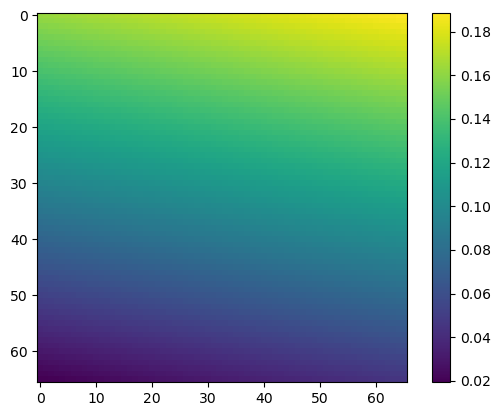

In [17]:
# Correct the chromatic abberation and plot the changes made to the FOV(s)

XimT_ = apply_colorcor(Xim_,m=m)
imTR = (XimT_-Xim_)[:,1].reshape(imT.shape)

plt.imshow(imTR)
plt.colorbar()

In [19]:
# can now load YFP spots for just a single FOV to assess how well chromatic correction is working

save_fl = analysis_folder+'/Conv_zscan__000_GFP2X.pkl.npy'
X1fov00,X2fov00 = np.load(save_fl)

X1fov00 = np.array(X1fov00)
X2fov00 = np.array(X2fov00)

In [20]:
# Apply chromatic correction to the FOV(s) loaded above for the YFP round of imaging

m = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ/chromatic_abberation_matrix_scope2.npy')
X1fov00T = apply_colorcor(X1fov00,m=m)
X2fov00T = apply_colorcor(X2fov00,m=m)

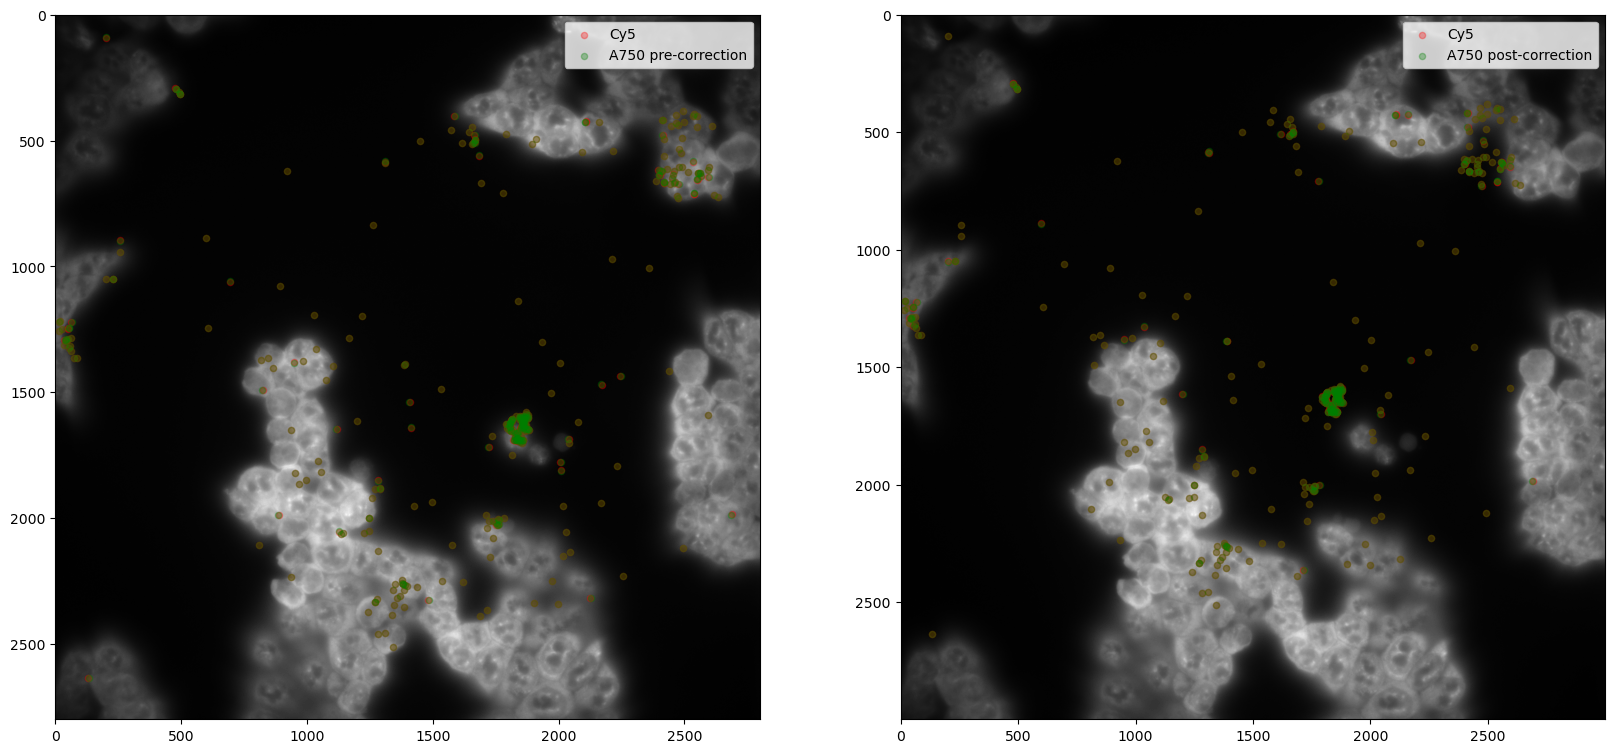

In [26]:
import matplotlib.pyplot as plt
from matplotlib import transforms
from skimage.transform import resize

# X1fov00 = np.transpose(X1fov00)
# X2fov00 = np.transpose(X2fov00)
# X1fov00T = np.transpose(X1fov00T)
# X2fov00T = np.transpose(X2fov00T)

img = read_im('/oasis/tscc/scratch/zgibbs/10_12_2023__CRE-20_RNASEQ/H9/Conv_zscan__000.zarr')
img_rs = resize(img[2,35,:,:], (3000,3000))

tr = transforms.Affine2D().rotate_deg(90)

fig, axs = plt.subplots(1, 2, figsize=(20,10))

axs[0].imshow(img[2,35,:,:], cmap='gray')
axs[0].scatter(X2fov00[:,2], X2fov00[:,1], s=20, c='r', alpha=0.3, label='Cy5')
axs[0].scatter(X1fov00[:,2], X1fov00[:,1], s=20, c='g', alpha=0.3, label='A750 pre-correction')
axs[0].legend()

axs[1].imshow(img_rs, cmap='gray')
axs[1].scatter(X2fov00[:,2], X2fov00[:,1], s=20, c='r', alpha=0.3, label='Cy5')
axs[1].scatter(X1fov00T[:,2], X1fov00T[:,1], s=20, c='g', alpha=0.3, label='A750 post-correction')
axs[1].legend()

# plt.gca().invert_yaxis()
# plt.gca().invert_xaxis()
plt.show()

## Perform drift correction

In [7]:
def drift_correction(hybes,fov,save_file,iiref=None,redo=False,ssz=20):
    if iiref is None: iiref = len(hybes)//2
    dic_drift = {}
    if os.path.exists(save_file):
        dic_drift = pickle.load(open(save_file,'rb'))
    tags = [os.path.basename(hybe) for hybe in hybes]
    redo = ~np.all([tag in dic_drift for tag in tags])
    if redo:
        #Load the reference dapi image
        fl1 = hybes[iiref]+os.sep+fov
        im1 = read_im(fl1)
        ncols,sz,sx,sy = im1.shape
        im1dapi = np.array(im1[-1][(sz-ssz)//2:(sz+ssz)//2],dtype=np.float32)
        ###Perform drift

        for hybe in tqdm(hybes):
            fl2 = hybe+os.sep+fov
            tag = os.path.basename(hybe)
            if not (tag in dic_drift):
                im2 = read_im(fl2)
                ncols,sz,sx,sy = im1.shape
                

                im2dapi = np.array(im2[-1][(sz-ssz)//2:(sz+ssz)//2],dtype=np.float32)
                txyz,txyzs = get_txyz(im1dapi,im2dapi,sz_norm=30,sz = 500,nelems=5)
                dic_drift[tag]=[txyz,txyzs]
                #print(txyz,txyzs)
                pickle.dump(dic_drift,open(save_file,'wb'))

In [8]:
# Perform the drift correction analysis for each FOV

for fov in tqdm(fovs):
    analysis_folder = '/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ/'
    save_file = analysis_folder+os.sep+fov.split('.')[0]+'_drift.pkl'
    
    drift_correction(hybes,fov,save_file,iiref=None,redo=False,ssz=20)

100%|██████████| 134/134 [5:49:23<00:00, 156.44s/it]


## Fit the CRE-barcode spots to drift- and chromatic abberation-corrected images

In [5]:
from scipy.signal import fftconvolve

def fit(hybe,fov,analysis_folder='/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ',icol=0,redo=False,hth = 50,plt_val=True):
    fl = hybe+os.sep+fov
    tag = os.path.basename(hybe)
    save_file=analysis_folder+os.sep+fov.split('.')[0]+'--'+tag+'_fits_icol'+str(icol)+'.npz'
    if not os.path.exists(save_file) or redo:
        im = read_im(fl)
        ncols,sz,sx,sy = im.shape
        #for icol in np.arange(ncols-1):
        imS = np.array(im[icol],dtype=np.float32) #GFP cy5 half
        #Convolve with gaussian 
        sz=5
        X = np.indices([2*sz+1]*3)-sz
        sigma=1.5
        gaussian = np.exp(-np.sum(X**2,axis=0)/2/sigma**2)
        im_conv = fftconvolve(imS,gaussian,mode='same')/np.sum(gaussian)
        #Subtract local background
        im_conv_ = norm_slice(im_conv,s=30)
        #fit the spots
        Xh = get_local_max(im_conv_,hth,im_raw=im_conv,delta=1,delta_fit=3)
        if plt_val:
            import napari
            v = napari.view_image(im_conv_)
            v.add_image(imS)
            h = Xh[:,-1]
            size = 5+np.clip(h/np.percentile(h,99.9),0,1)*10
            v.add_points(Xh[:,:3],size=size,face_color=[0,0,0,0],edge_color='y')
        np.savez_compressed(save_file,Xh=Xh)

In [6]:
def tag_to_hybe(tag):
    try:
        return int(tag[1:])
    except:
        return -1

def get_XH(save_folder='something', fov='something', ncols=3, chromatic_fl='something', drift_fl='something'):
        """Load in the fitted dots for each field of view.
        Apply chromatic abberation correction and drift correction and append corrected fitted data 
        int self.XH structure"""
        ncols = ncols
        drift_dic = pickle.load(open(drift_fl,'rb'))
        tags = list(drift_dic.keys())
        if not os.path.exists(chromatic_fl):
            self.m=None
        else:
            m = np.load(chromatic_fl)
        XH = []
        save_folder = save_folder
        fov = fov
        for tag in tqdm(tags):
            iH = tag_to_hybe(tag)
            for icol in range(ncols):
                #tag = os.path.basename(fld)#Conv_zscan__30--H_GFP_fits_icol0
                save_fl = save_folder+os.sep+fov.split('.')[0]+'--'+tag+'_fits_icol'+str(icol)+'.npz'
                Xh = np.load(save_fl)['Xh']
                tzxy = drift_dic[tag][0]
                m=None
                if icol==0: m=m
                Xh[:,:3] = apply_colorcor(Xh[:,:3],m=m)
                Xh[:,:3]+=tzxy# drift correction
                #chromatic abberation -to check
                ### took out code for assigning bits to array ###
        XH = np.array(Xh)

In [7]:
for fov in tqdm(fovs):
    for hybe in hybes[:8]:
        for icol in range(3):
            fit(hybe, fov,icol=icol,analysis_folder='/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ',redo=False,hth = 50,plt_val=False)

 91%|█████████ | 167/184 [00:20<00:00, 115.94it/s]/projects/ps-renlab2/zgibbs/STARR-FISH/ioMicro.py:598: RuntimeWarning: invalid value encountered in true_divide
  im_centers__ = (im_centers__-np.mean(im_centers__,axis=-1)[:,np.newaxis])/np.std(im_centers__,axis=-1)[:,np.newaxis]
/projects/ps-renlab2/zgibbs/STARR-FISH/ioMicro.py:601: RuntimeWarning: invalid value encountered in true_divide
  zc = np.sum(im_centers_[0]*im_centers_[3],axis=0)/np.sum(im_centers_[3],axis=0)
/projects/ps-renlab2/zgibbs/STARR-FISH/ioMicro.py:602: RuntimeWarning: invalid value encountered in true_divide
  xc = np.sum(im_centers_[1]*im_centers_[3],axis=0)/np.sum(im_centers_[3],axis=0)
/projects/ps-renlab2/zgibbs/STARR-FISH/ioMicro.py:603: RuntimeWarning: invalid value encountered in true_divide
  yc = np.sum(im_centers_[2]*im_centers_[3],axis=0)/np.sum(im_centers_[3],axis=0)
100%|██████████| 184/184 [3:27:11<00:00, 67.56s/it] 


In [11]:
get_XH(save_folder='/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc',
       fov='Conv_zscan__000', ncols=3,
       chromatic_fl='/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/chromatic_abberation_matrix_scope4.npy',
       drift_fl='/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__000_drift.pkl')

100%|██████████| 9/9 [00:00<00:00, 18.99it/s]


In [ ]:
# Each column in fit spots output array (Xh):
# 0) zc
# 1) xc
# 2) yc
# 3) bk (?)
# 4) a
# 5) habs (absolute brightness from scope)
# 6) correlation with PSF
# 7) h (relative/normalized brightness?)

In [116]:
CRE001_H1 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__000--H1_fits_icol0.npz')['Xh']

In [40]:
CRE001_H1[:,4]

array([ 40253.28613281,  23335.00415039,  20463.72009277, ...,
        12539.27429199,  44301.23681641, 118556.47021484])

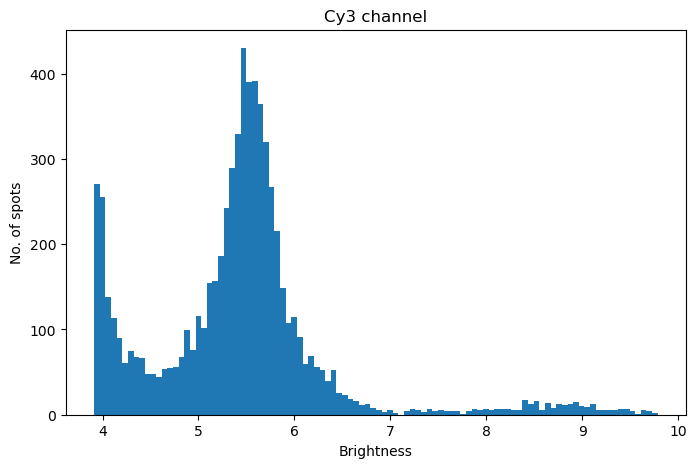

In [171]:
CRE003_H1 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__019--H1_fits_icol2.npz')['Xh']

fig, ax = plt.subplots(figsize=(8,5))

ax.hist(np.log(CRE003_H1[:,7]), bins=100)
ax.set_title('Cy3 channel')
ax.set_ylabel('No. of spots')
ax.set_xlabel('Brightness')

plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/brightness_hist_Cy3.png', dpi=300)

In [312]:
np.exp(5.7)

298.8674009670603

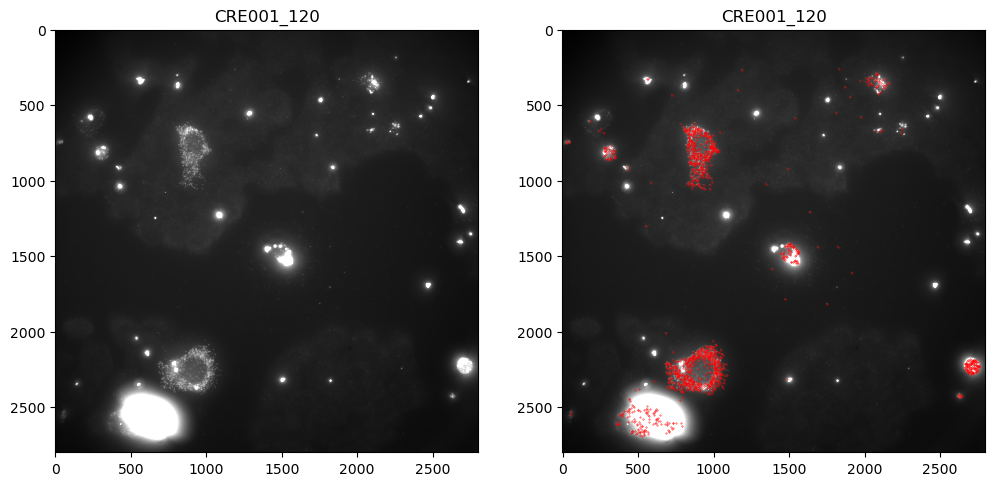

In [9]:
import matplotlib.pyplot as plt

CRE001_000 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__120--H1_fits_icol0.npz')['Xh']
h = CRE001_000[:,7]
keep = np.where((h>665) & (h<1800))
CRE001_000_ = CRE001_000[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H1/Conv_zscan__120.zarr')

fig, axs = plt.subplots(1, 2, figsize=(12,6))

axs[0].imshow(np.max(img[0,:,:], axis=0), vmax=6000, cmap='gray')
axs[0].set_title('CRE001_120')

# axs[1].imshow(np.max(img[0,:,:], axis=0), vmax=4000, cmap='gray')
# axs[1].scatter(CRE001_000[:,2], CRE001_000[:,1], s=0.25, c='r')
# axs[1].set_title('CRE001_019')

axs[1].imshow(np.max(img[0,:,:], axis=0), vmax=6000, cmap='gray')
axs[1].scatter(CRE001_000_[:,2], CRE001_000_[:,1], s=0.1, c='r')
axs[1].set_title('CRE001_120')

# plt.gca().invert_yaxis()
# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/CRE001_120_filtered_spots.png', dpi=450)

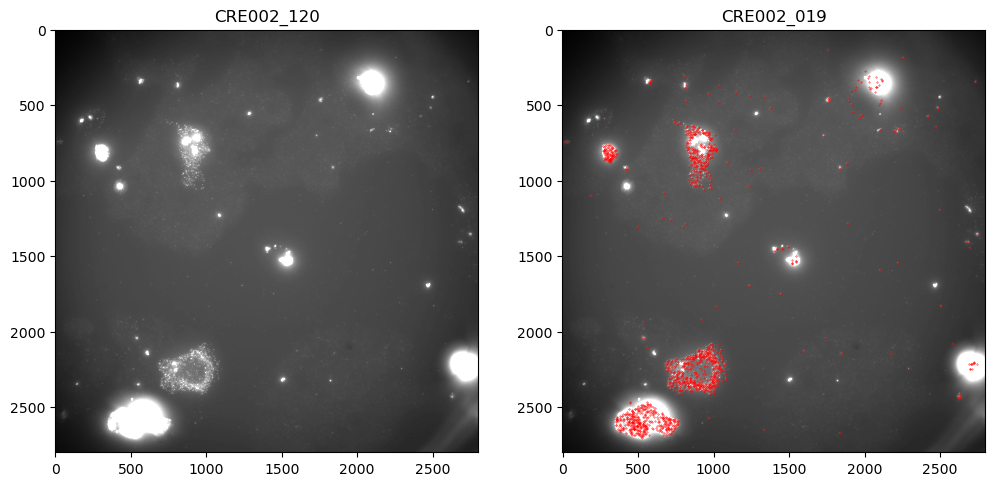

In [15]:
import matplotlib.pyplot as plt

CRE002_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__120--H1_fits_icol1.npz')['Xh']
h = CRE002_001[:,7]
keep = np.where((h>665) & (h<1800))
CRE002_001_ = CRE002_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H1/Conv_zscan__120.zarr')

fig, axs = plt.subplots(1, 2, figsize=(12,6))

axs[0].imshow(np.max(img[1,:,:], axis=0), vmax=5500, cmap='gray')
axs[0].set_title('CRE002_120')

# axs[1].imshow(np.max(img[1,:,:], axis=0), vmax=4500, cmap='gray')
# axs[1].scatter(CRE002_001[:,2], CRE002_001[:,1], s=0.25, c='r')
# axs[1].set_title('CRE002_019')

axs[1].imshow(np.max(img[1,:,:], axis=0), vmax=5500, cmap='gray')
axs[1].scatter(CRE002_001_[:,2], CRE002_001_[:,1], s=0.1, c='r')
axs[1].set_title('CRE002_019')

# plt.gca().invert_yaxis()

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/CRE002_120_filtered_spots.png', dpi=450)

Text(0.5, 1.0, 'CRE003_019')

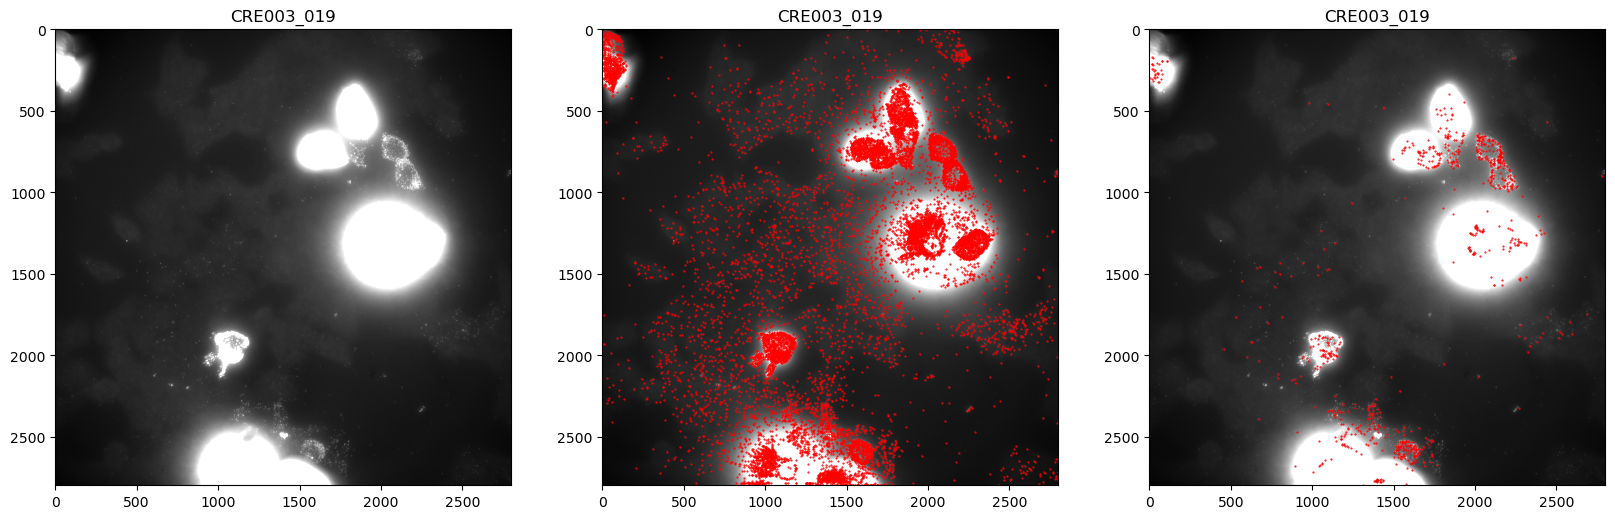

In [11]:
import matplotlib.pyplot as plt

CRE003_000 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__093--H1_fits_icol2.npz')['Xh']
h = CRE003_000[:,7]
keep = np.where((h>250) & (h<300))
CRE003_000_ = CRE003_000[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H1/Conv_zscan__093.zarr')

fig, axs = plt.subplots(1, 3, figsize=(20,20))

axs[0].imshow(np.max(img[2,:,:], axis=0), vmax=2000, cmap='gray')
axs[0].set_title('CRE003_019')

axs[1].imshow(np.max(img[2,:,:], axis=0), vmax=2000, cmap='gray')
axs[1].scatter(CRE003_000[:,2], CRE003_000[:,1], s=0.25, c='r')
axs[1].set_title('CRE003_019')

axs[2].imshow(np.max(img[2,:,:], axis=0), vmax=2000, cmap='gray')
axs[2].scatter(CRE003_000_[:,2], CRE003_000_[:,1], s=0.25, c='r')
axs[2].set_title('CRE003_019')

# plt.gca().invert_yaxis()

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/CRE003_019_filtered_spots.png', dpi=450)

Text(0.5, 1.0, 'CRE004_001')

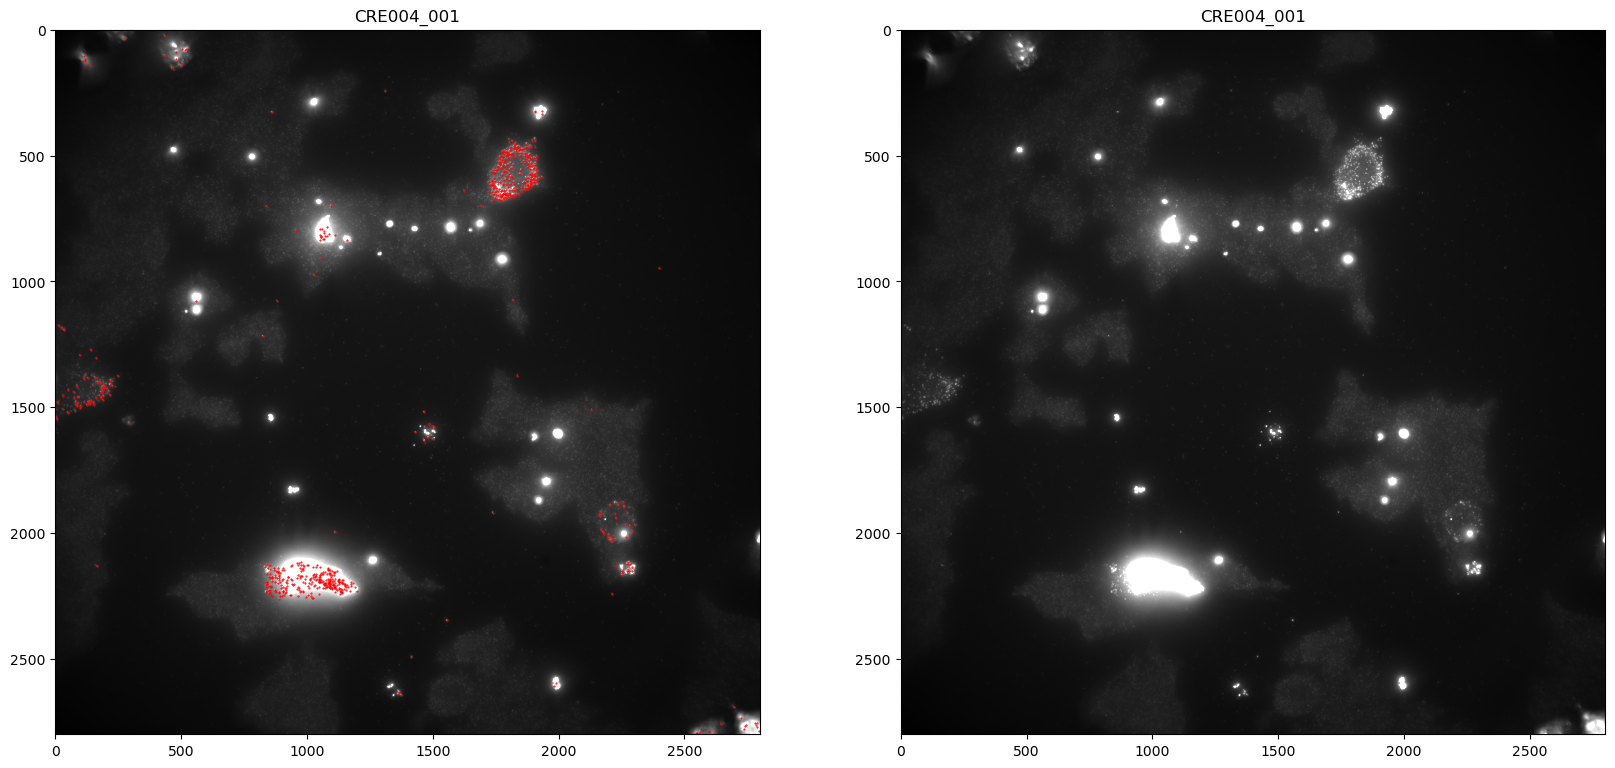

In [14]:
import matplotlib.pyplot as plt

CRE004_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__086--H2_fits_icol0.npz')['Xh']
h = CRE004_001[:,7]
keep = np.where((h>500) & (h<2000))
CRE004_001_ = CRE004_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H2/Conv_zscan__086.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[0,:,:], axis=0), vmax=4000, cmap='gray')
axs[0].scatter(CRE004_001_[:,2], CRE004_001_[:,1], s=0.25, c='r')
axs[0].set_title('CRE004_001')

axs[1].imshow(np.max(img[0,:,:], axis=0), vmax=4000, cmap='gray')
axs[1].set_title('CRE004_001')
# plt.gca().invert_yaxis()

Text(0.5, 1.0, 'CRE005_008')

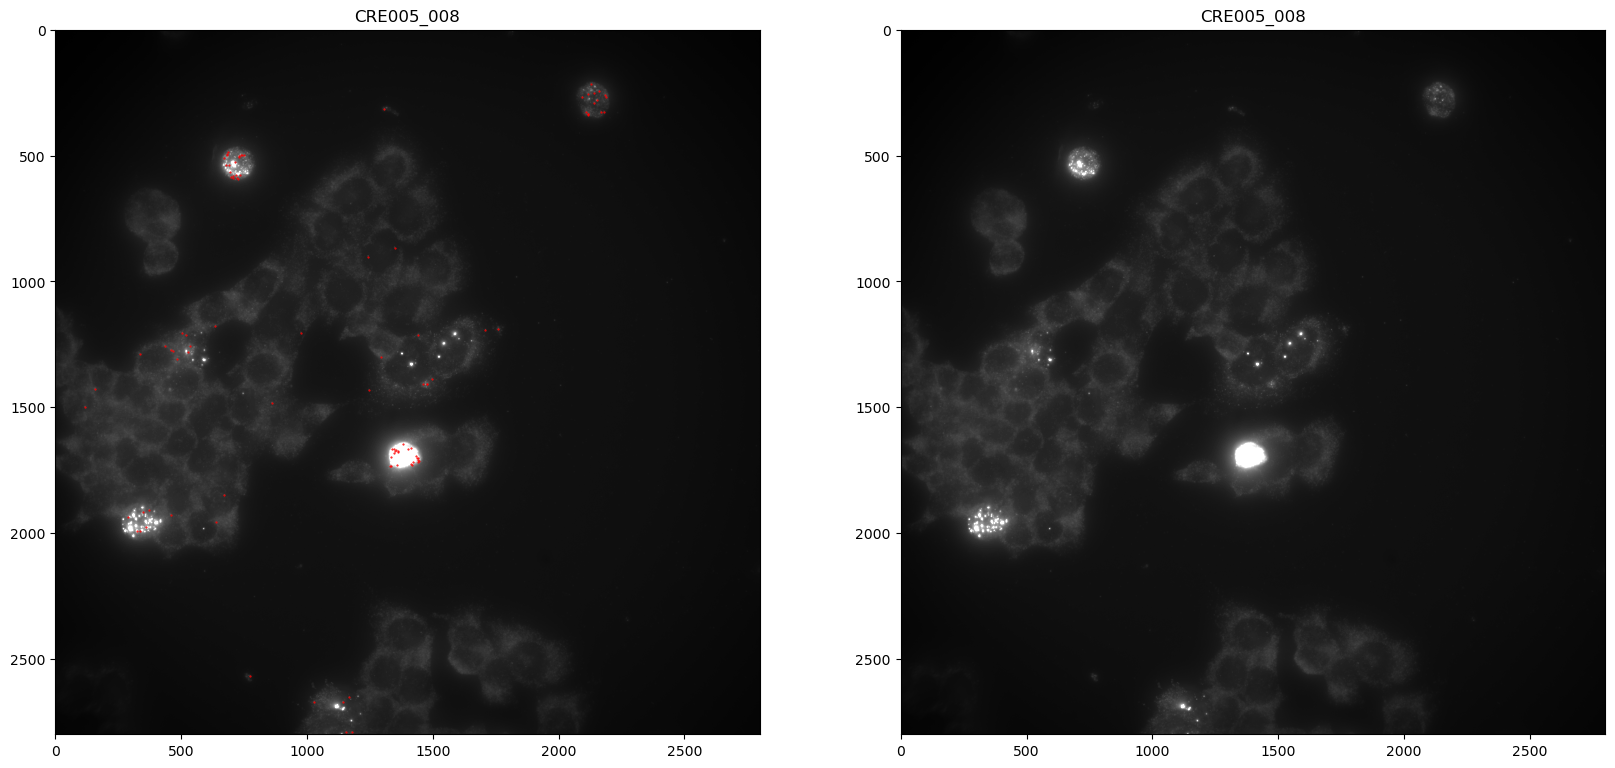

In [27]:
import matplotlib.pyplot as plt

CRE005_008 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__109--H2_fits_icol1.npz')['Xh']
h = CRE005_008[:,7]
keep = np.where((h>1500) & (h<2000))
CRE005_008_ = CRE005_008[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H2/Conv_zscan__109.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[1,:,:], axis=0), vmax=17000, cmap='gray')
axs[0].scatter(CRE005_008_[:,2], CRE005_008_[:,1], s=0.25, c='r')
axs[0].set_title('CRE005_008')

axs[1].imshow(np.max(img[1,:,:], axis=0), vmax=17000, cmap='gray')
axs[1].set_title('CRE005_008')
# plt.gca().invert_yaxis()

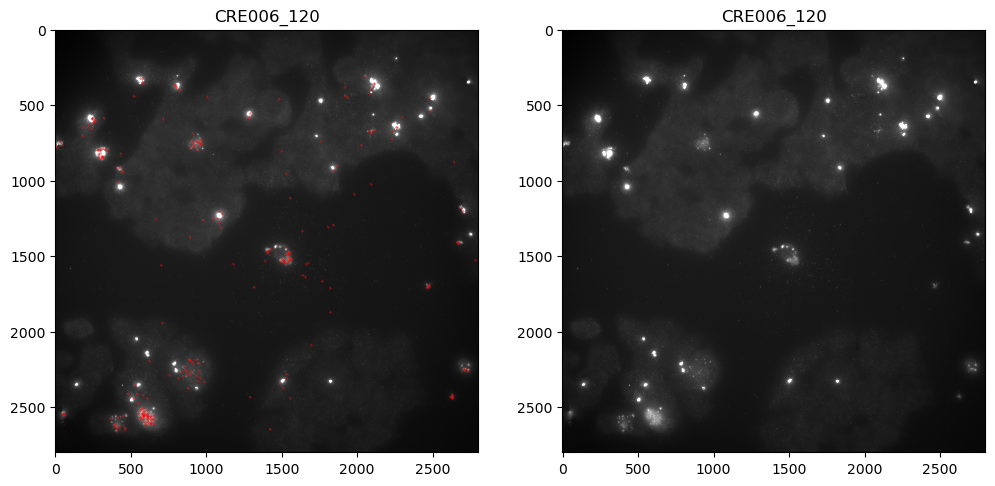

In [20]:
import matplotlib.pyplot as plt

CRE006_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__120--H2_fits_icol2.npz')['Xh']
h = CRE006_001[:,7]
keep = np.where((h>200) & (h<400))
CRE006_001_ = CRE006_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H2/Conv_zscan__120.zarr')

fig, axs = plt.subplots(1, 2, figsize=(12,6))

axs[0].imshow(np.max(img[2,:,:], axis=0), vmax=2000, cmap='gray')
axs[0].scatter(CRE006_001_[:,2], CRE006_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE006_120')

axs[1].imshow(np.max(img[2,:,:], axis=0), vmax=2000, cmap='gray')
axs[1].set_title('CRE006_120')
# plt.gca().invert_yaxis()

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/CRE006_120_filtered_spots.png', dpi=450)

Text(0.5, 1.0, 'CRE007_001')

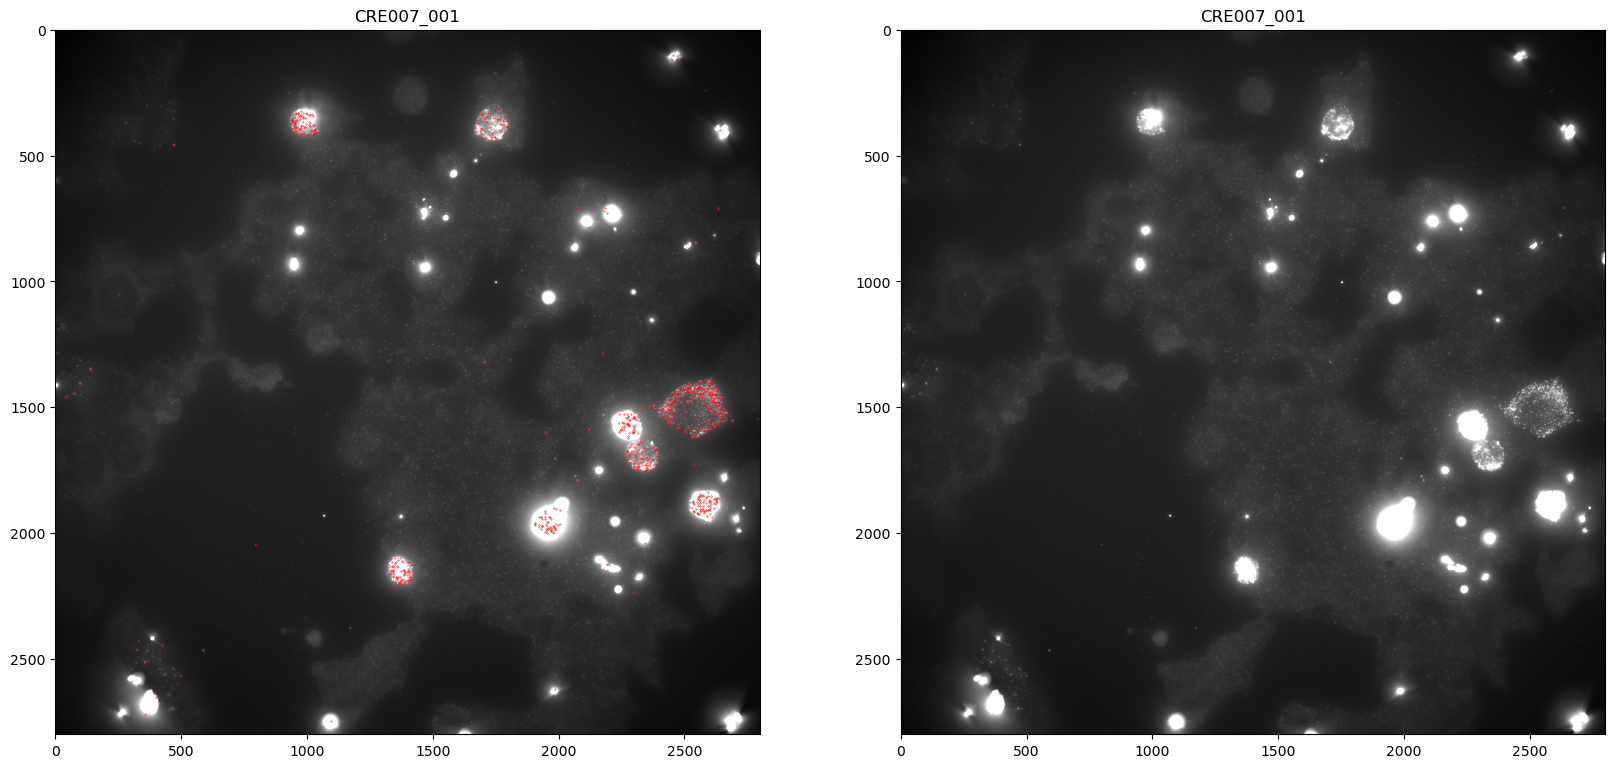

In [35]:
import matplotlib.pyplot as plt

CRE007_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__122--H3_fits_icol0.npz')['Xh']
h = CRE007_001[:,7]
keep = np.where((h>400) & (h<1000))
CRE007_001_ = CRE007_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H3/Conv_zscan__122.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[0,:,:], axis=0), vmax=3000, cmap='gray')
axs[0].scatter(CRE007_001_[:,2], CRE007_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE007_001')

axs[1].imshow(np.max(img[0,:,:], axis=0), vmax=3000, cmap='gray')
axs[1].set_title('CRE007_001')
# plt.gca().invert_yaxis()

Text(0.5, 1.0, 'CRE008_001')

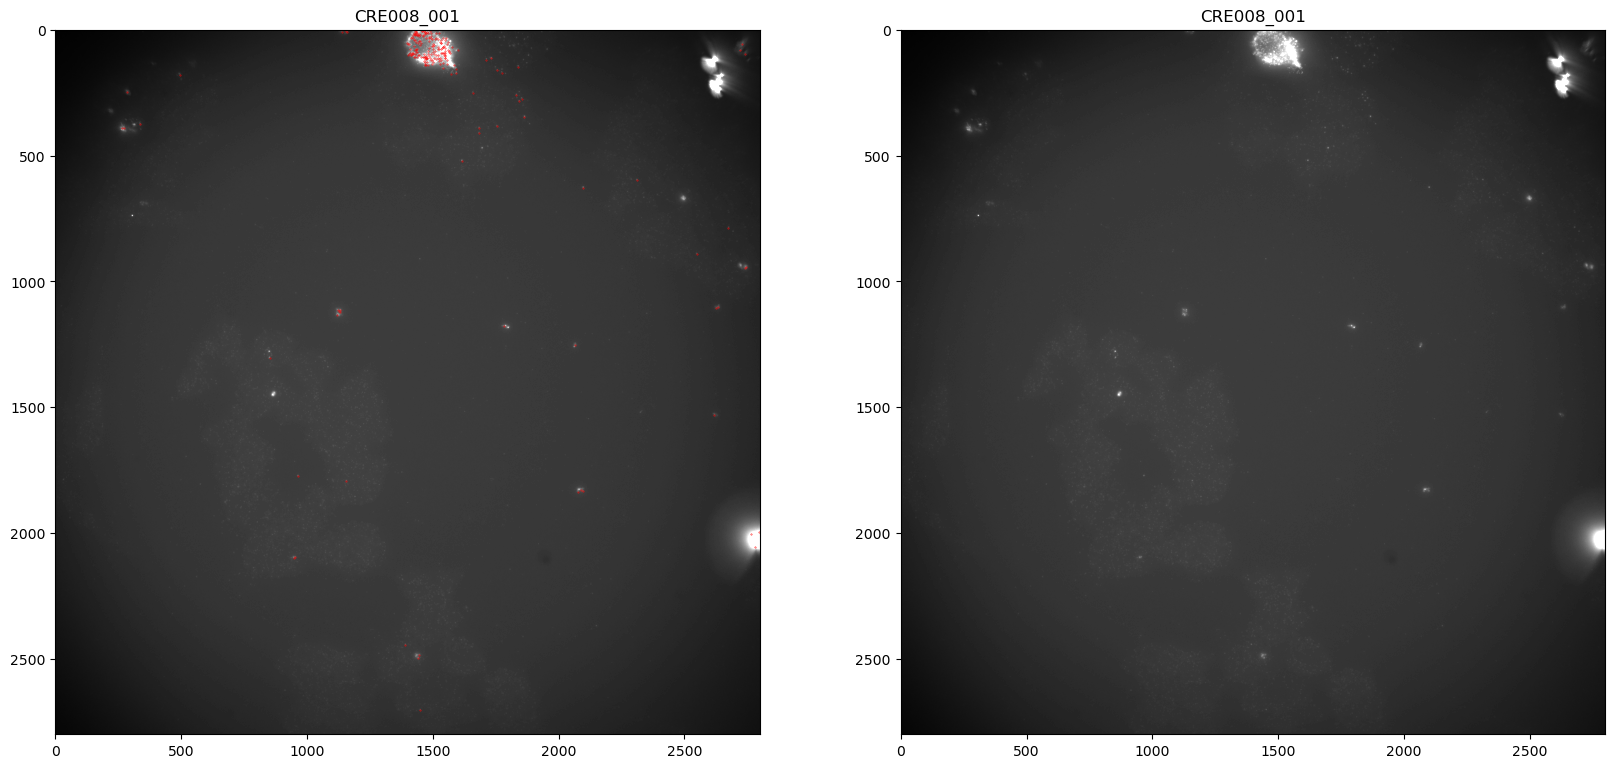

In [38]:
import matplotlib.pyplot as plt

CRE008_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__102--H3_fits_icol1.npz')['Xh']
h = CRE008_001[:,7]
keep = np.where((h>450) & (h<1000))
CRE008_001_ = CRE008_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H3/Conv_zscan__102.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[1,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].scatter(CRE008_001_[:,2], CRE008_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE008_001')

axs[1].imshow(np.max(img[1,:,:], axis=0), vmax=5000, cmap='gray')
axs[1].set_title('CRE008_001')
# plt.gca().invert_yaxis()

Text(0.5, 1.0, 'CRE009_001')

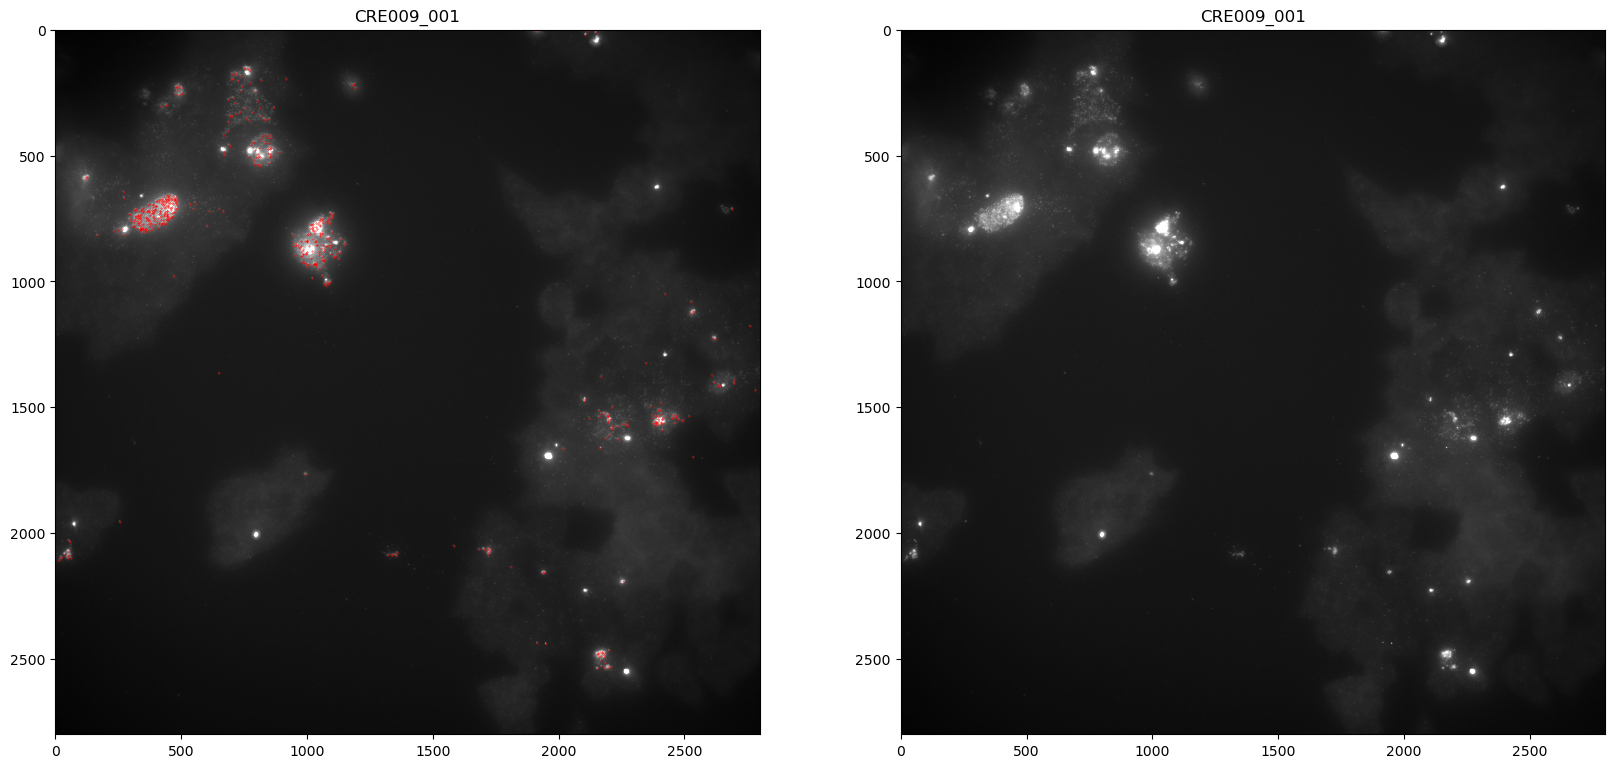

In [46]:
import matplotlib.pyplot as plt

CRE009_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__085--H3_fits_icol2.npz')['Xh']
h = CRE009_001[:,7]
keep = np.where((h>200) & (h<1000))
CRE009_001_ = CRE009_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H3/Conv_zscan__085.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[2,:,:], axis=0), vmax=2000, cmap='gray')
axs[0].scatter(CRE009_001_[:,2], CRE009_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE009_001')

axs[1].imshow(np.max(img[2,:,:], axis=0), vmax=2000, cmap='gray')
axs[1].set_title('CRE009_001')
# plt.gca().invert_yaxis()

Text(0.5, 1.0, 'CRE010_001')

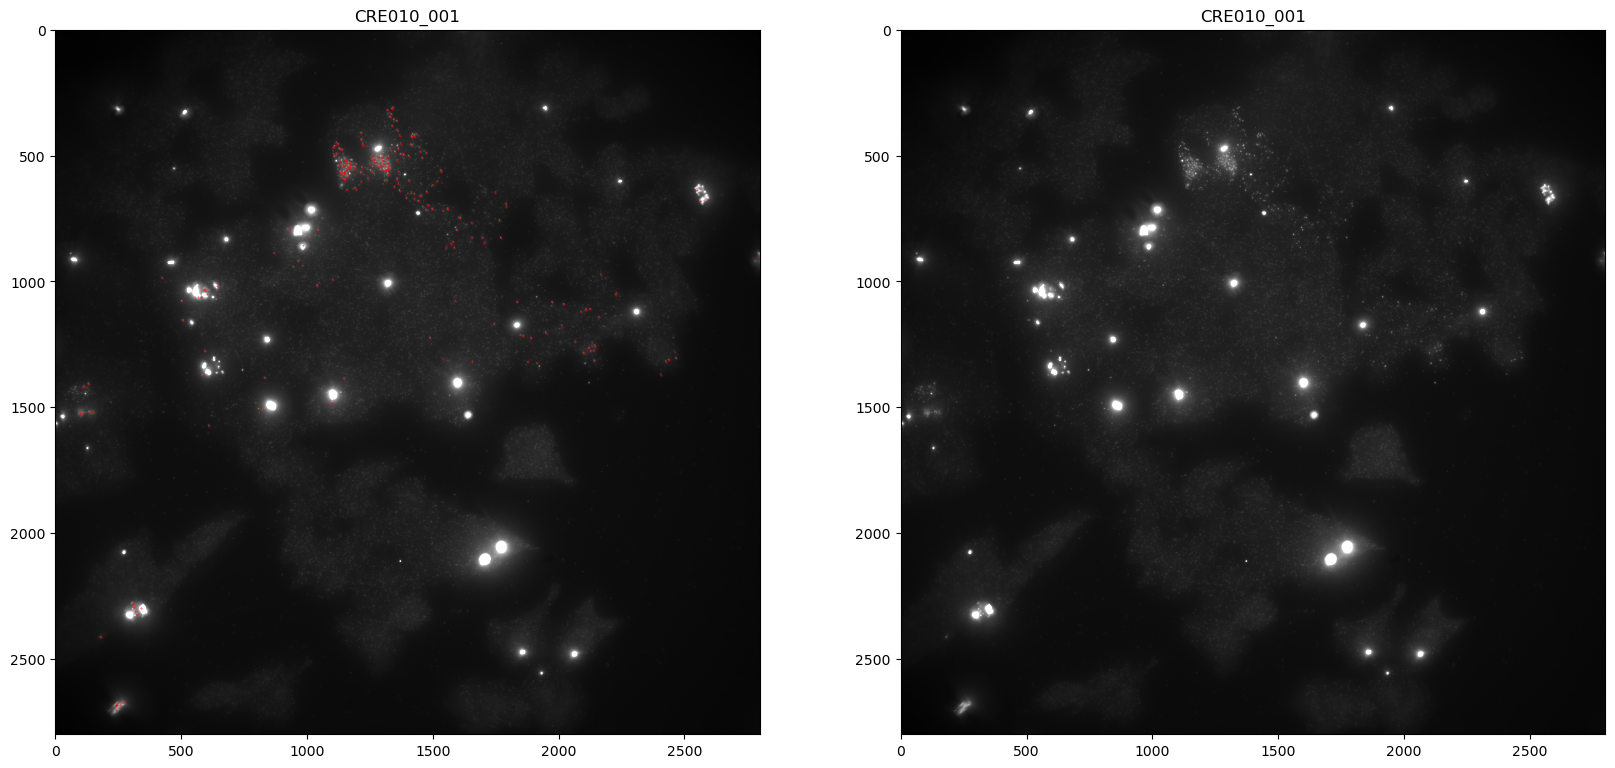

In [51]:
import matplotlib.pyplot as plt

CRE010_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__056--H4_fits_icol0.npz')['Xh']
h = CRE010_001[:,7]
keep = np.where((h>500) & (h<1000))
CRE010_001_ = CRE010_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H4/Conv_zscan__056.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[0,:,:], axis=0), vmax=4000, cmap='gray')
axs[0].scatter(CRE010_001_[:,2], CRE010_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE010_001')

axs[1].imshow(np.max(img[0,:,:], axis=0), vmax=4000, cmap='gray')
axs[1].set_title('CRE010_001')
# plt.gca().invert_yaxis()

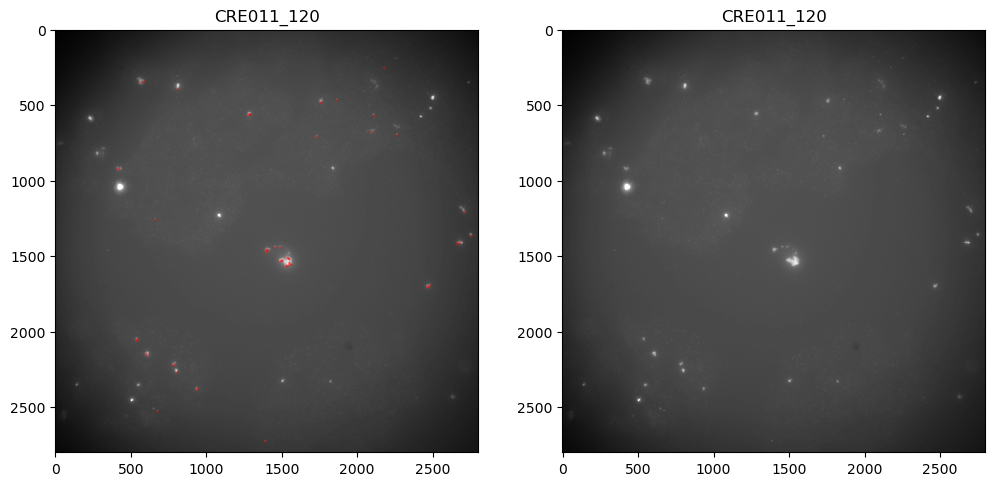

In [23]:
import matplotlib.pyplot as plt

CRE011_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__120--H4_fits_icol1.npz')['Xh']
h = CRE011_001[:,7]
keep = np.where((h>600) & (h<1000))
CRE011_001_ = CRE011_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H4/Conv_zscan__120.zarr')

fig, axs = plt.subplots(1, 2, figsize=(12,6))

axs[0].imshow(np.max(img[1,:,:], axis=0), vmax=4000, cmap='gray')
axs[0].scatter(CRE011_001_[:,2], CRE011_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE011_120')

axs[1].imshow(np.max(img[1,:,:], axis=0), vmax=4000, cmap='gray')
axs[1].set_title('CRE011_120')
# plt.gca().invert_yaxis()

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/CRE011_120_filtered_spots.png', dpi=450)

Text(0.5, 1.0, 'CRE012_001')

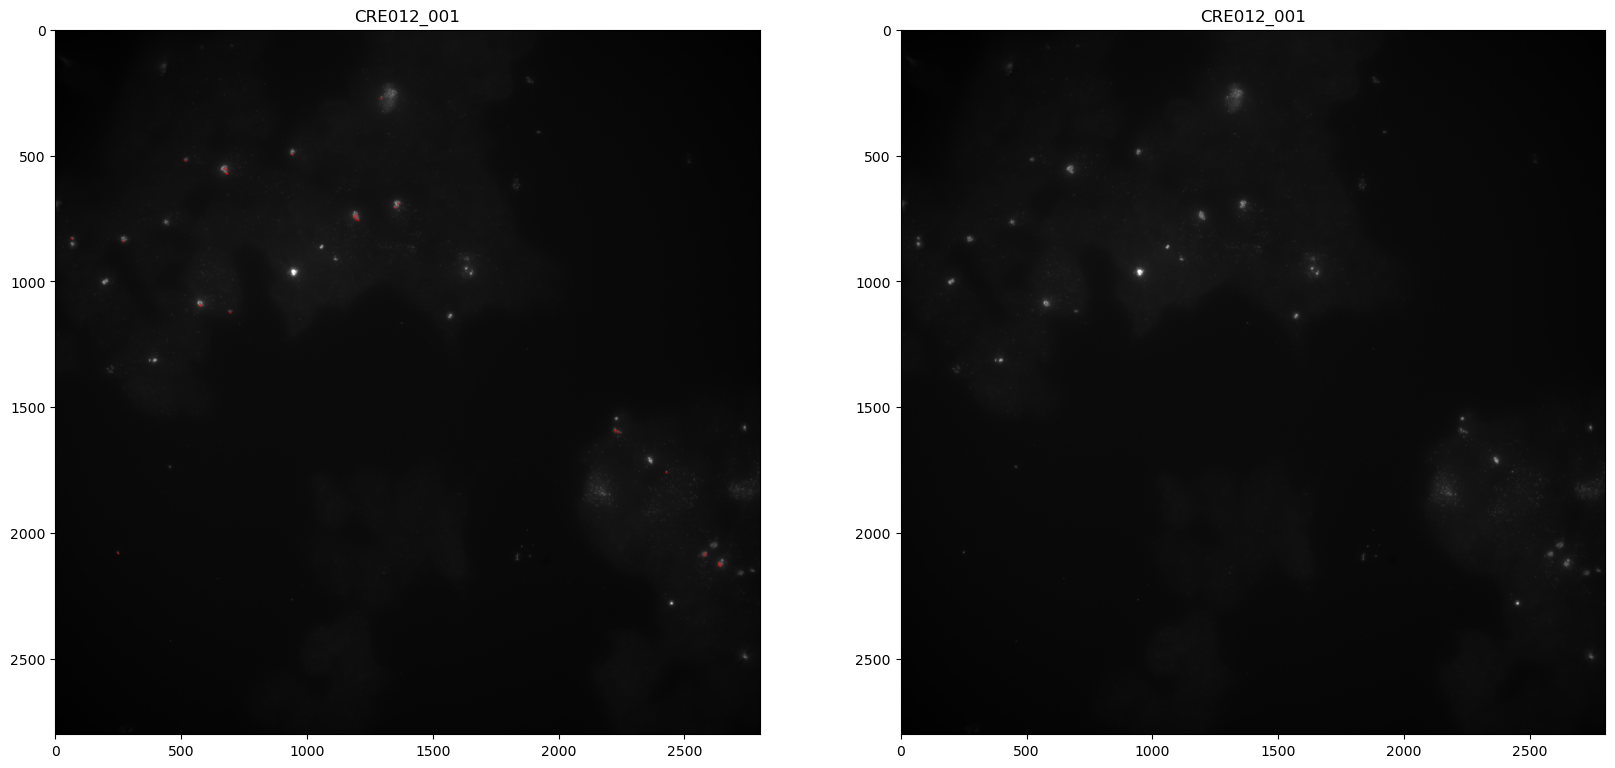

In [60]:
import matplotlib.pyplot as plt

CRE012_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__047--H4_fits_icol2.npz')['Xh']
h = CRE012_001[:,7]
keep = np.where((h>600) & (h<800))
CRE012_001_ = CRE012_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H4/Conv_zscan__047.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[2,:,:], axis=0), vmax=4000, cmap='gray')
axs[0].scatter(CRE012_001_[:,2], CRE012_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE012_001')

axs[1].imshow(np.max(img[2,:,:], axis=0), vmax=4000, cmap='gray')
axs[1].set_title('CRE012_001')
# plt.gca().invert_yaxis()

Text(0.5, 1.0, 'CRE013_001')

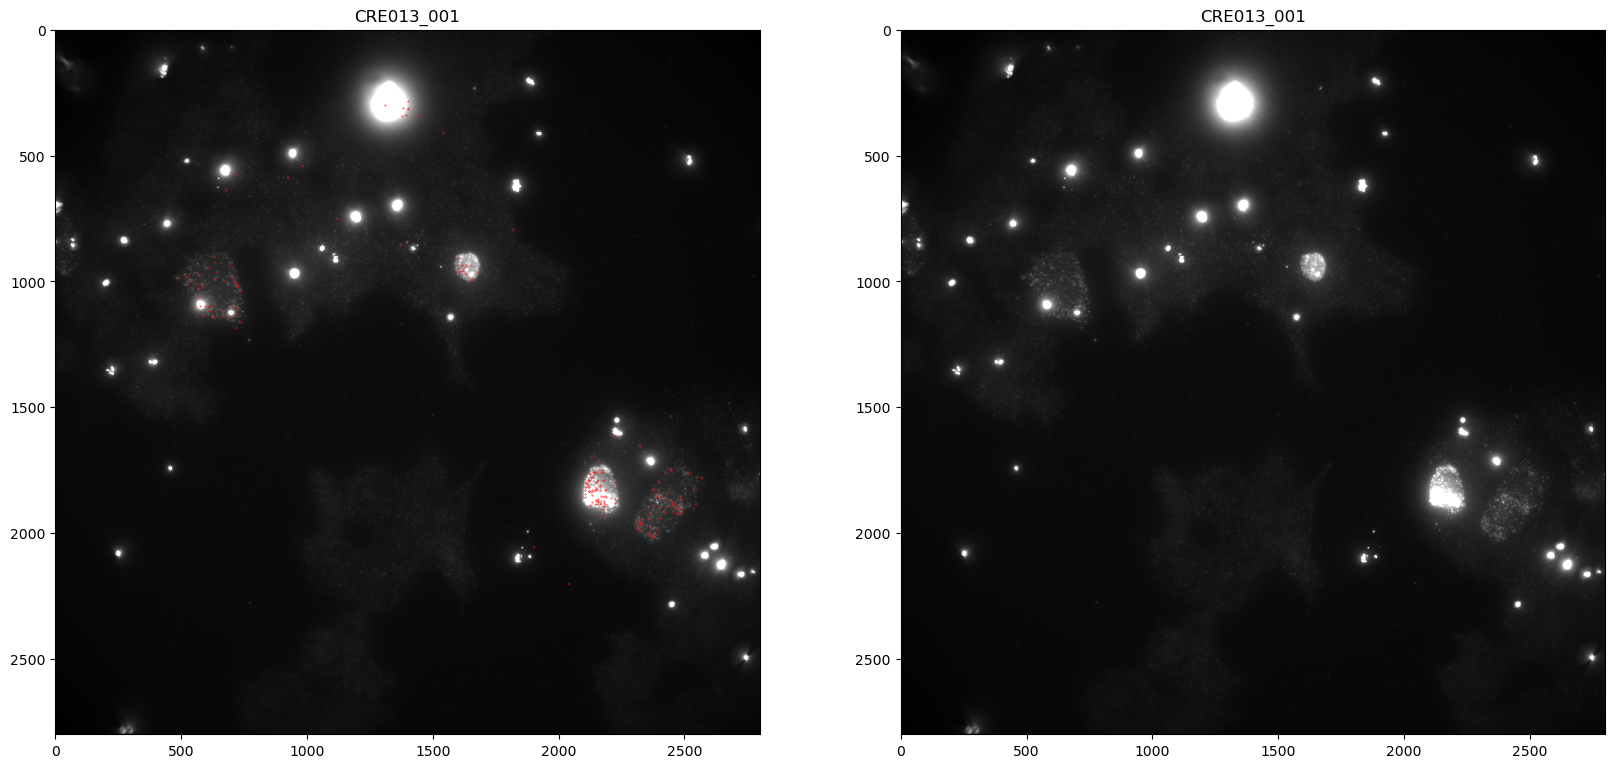

In [64]:
import matplotlib.pyplot as plt

CRE013_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__047--H5_fits_icol0.npz')['Xh']
h = CRE013_001[:,7]
keep = np.where((h>600) & (h<800))
CRE013_001_ = CRE013_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H5/Conv_zscan__047.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[0,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].scatter(CRE013_001_[:,2], CRE013_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE013_001')

axs[1].imshow(np.max(img[0,:,:], axis=0), vmax=5000, cmap='gray')
axs[1].set_title('CRE013_001')
# plt.gca().invert_yaxis()

Text(0.5, 1.0, 'CRE014_001')

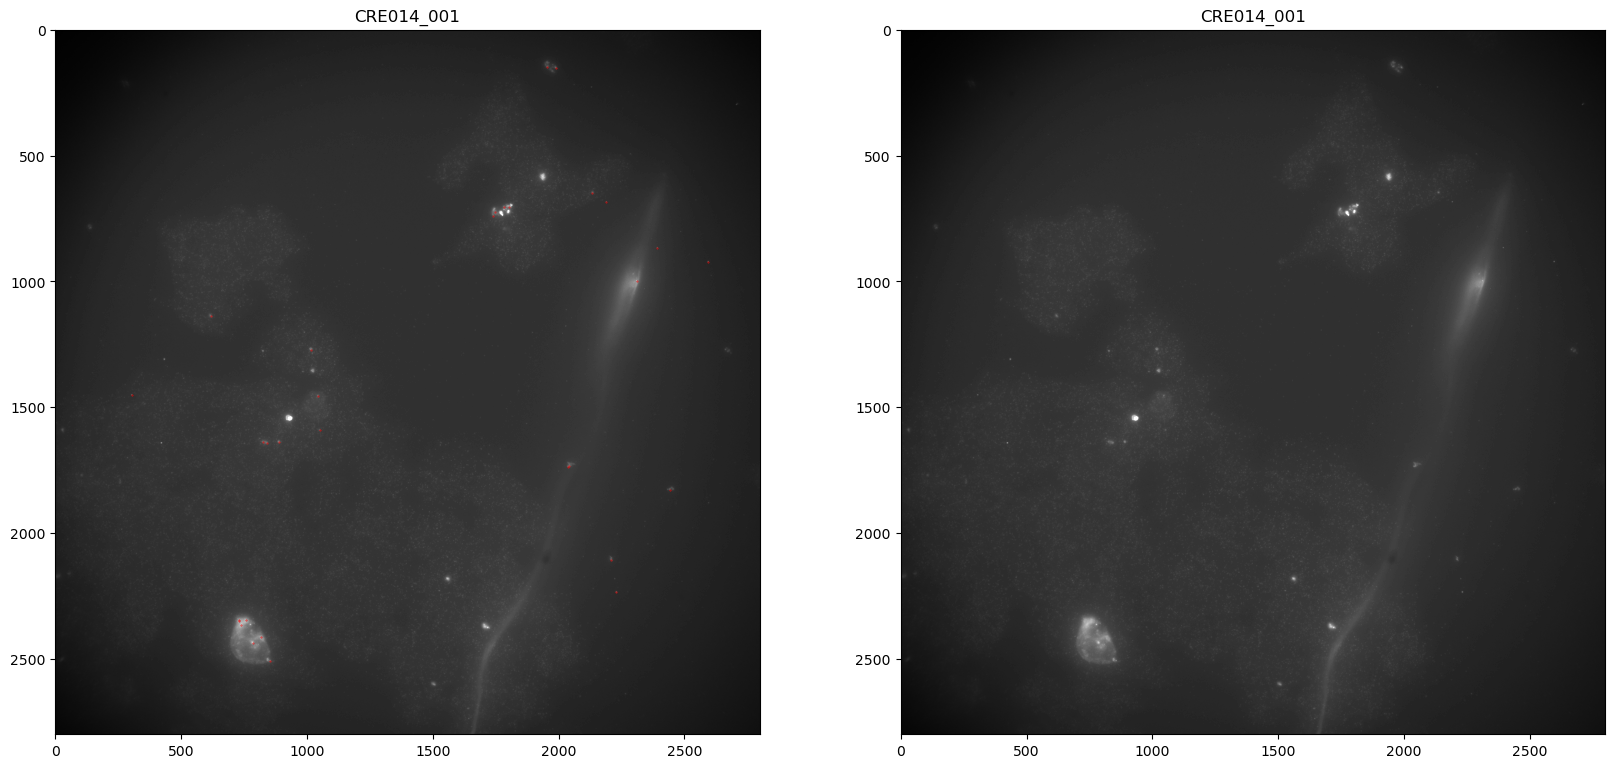

In [66]:
import matplotlib.pyplot as plt

CRE014_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__048--H5_fits_icol1.npz')['Xh']
h = CRE014_001[:,7]
keep = np.where((h>600) & (h<1000))
CRE014_001_ = CRE014_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H5/Conv_zscan__048.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[1,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].scatter(CRE014_001_[:,2], CRE014_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE014_001')

axs[1].imshow(np.max(img[1,:,:], axis=0), vmax=5000, cmap='gray')
axs[1].set_title('CRE014_001')
# plt.gca().invert_yaxis()

Text(0.5, 1.0, 'CRE015_001')

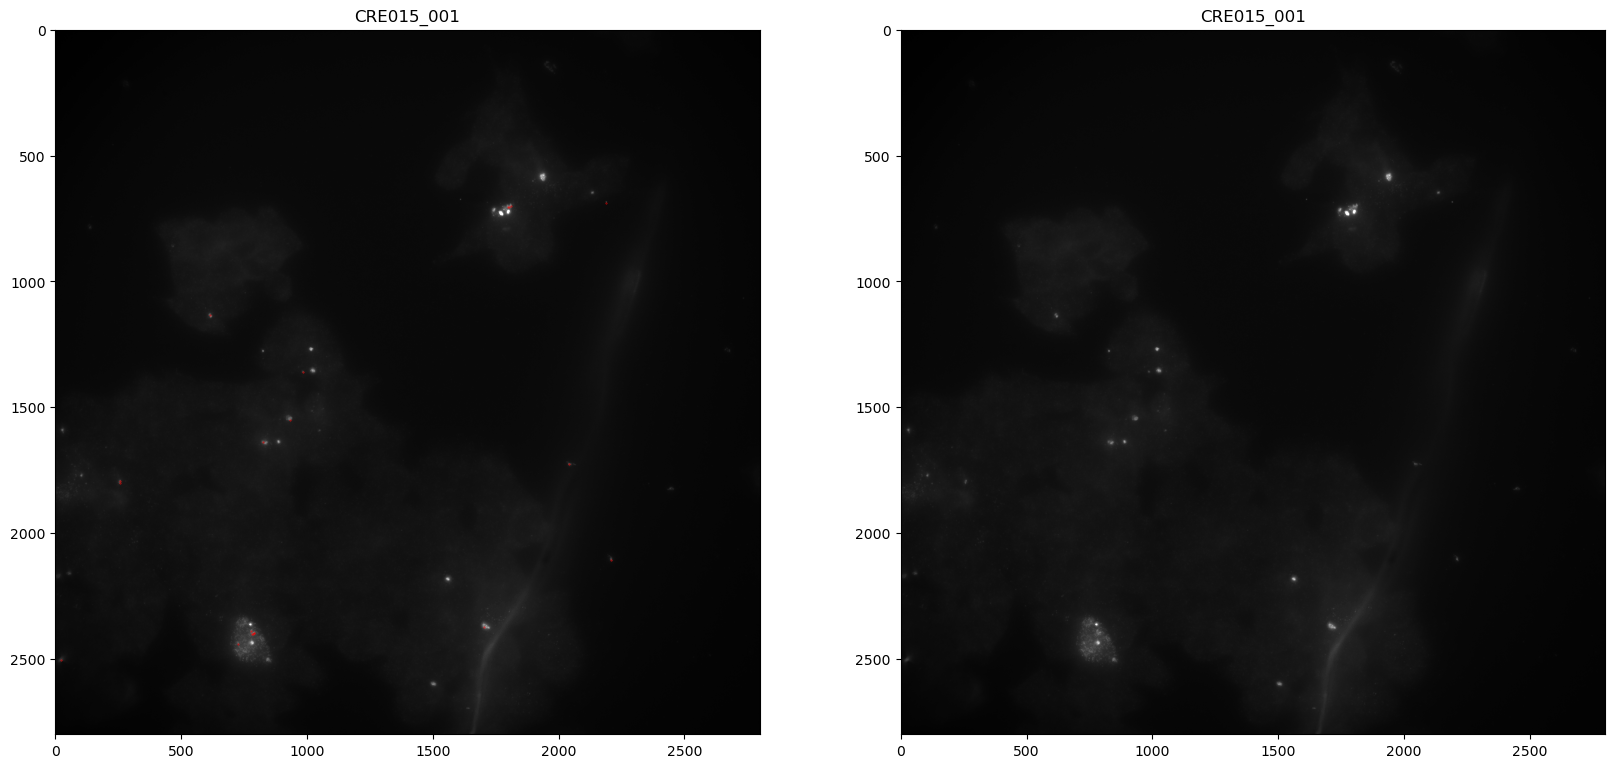

In [68]:
import matplotlib.pyplot as plt

CRE015_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__048--H5_fits_icol2.npz')['Xh']
h = CRE015_001[:,7]
keep = np.where((h>600) & (h<1000))
CRE015_001_ = CRE015_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H5/Conv_zscan__048.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[2,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].scatter(CRE015_001_[:,2], CRE015_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE015_001')

axs[1].imshow(np.max(img[2,:,:], axis=0), vmax=5000, cmap='gray')
axs[1].set_title('CRE015_001')
# plt.gca().invert_yaxis()

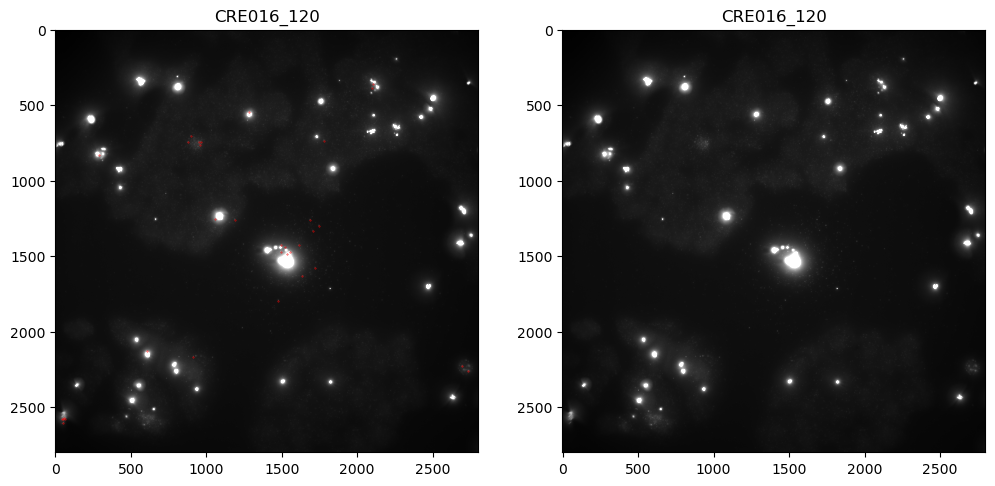

In [25]:
import matplotlib.pyplot as plt

CRE016_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__120--H6_fits_icol0.npz')['Xh']
h = CRE016_001[:,7]
keep = np.where((h>700) & (h<1000))
CRE016_001_ = CRE016_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H6/Conv_zscan__120.zarr')

fig, axs = plt.subplots(1, 2, figsize=(12,6))

axs[0].imshow(np.max(img[0,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].scatter(CRE016_001_[:,2], CRE016_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE016_120')

axs[1].imshow(np.max(img[0,:,:], axis=0), vmax=5000, cmap='gray')
axs[1].set_title('CRE016_120')
# plt.gca().invert_yaxis()

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/CRE016_120_filtered_spots.png', dpi=450)

Text(0.5, 1.0, 'CRE017_001')

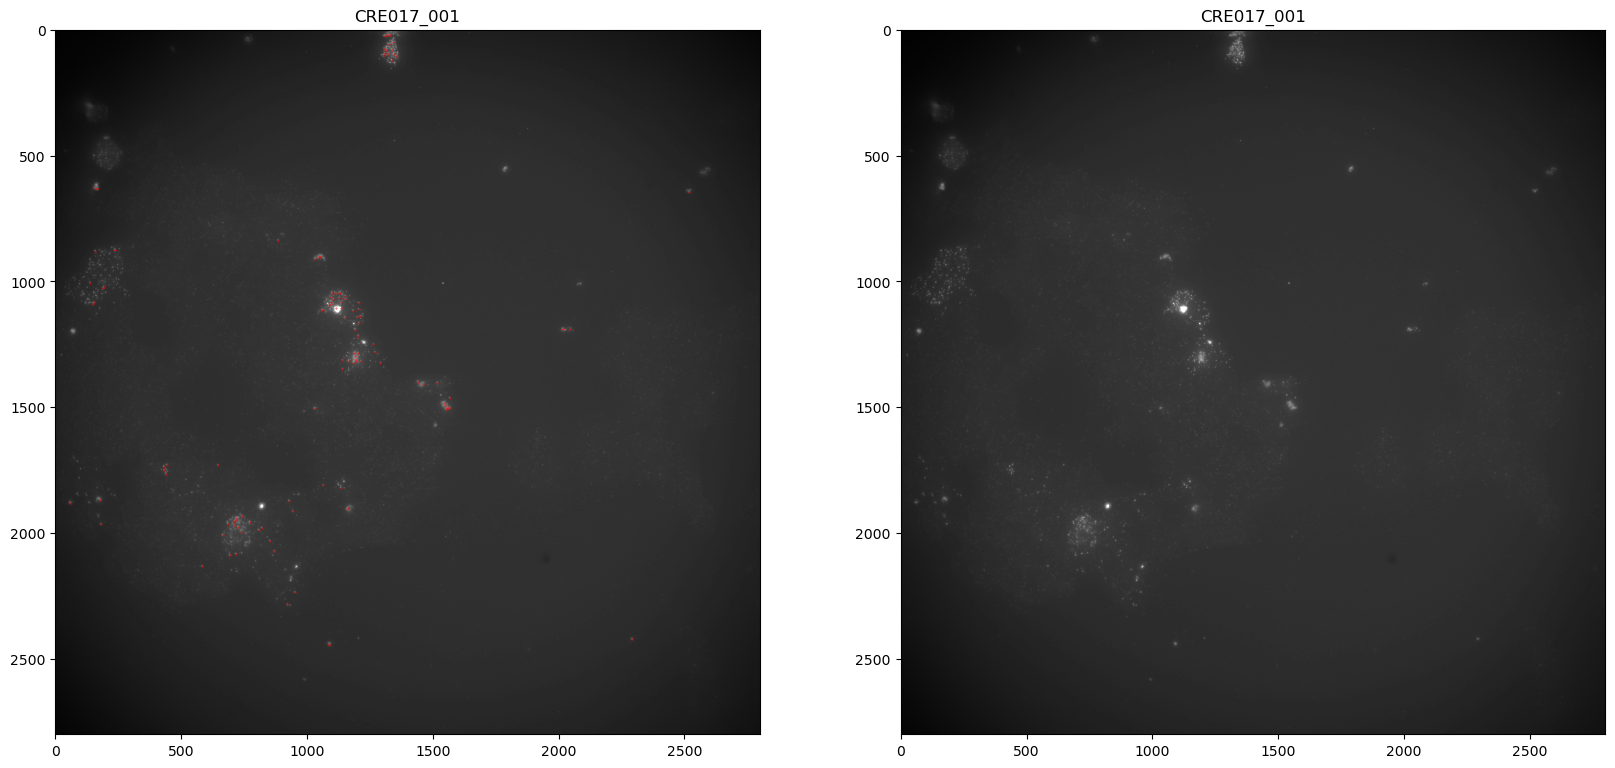

In [73]:
import matplotlib.pyplot as plt

CRE017_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__051--H6_fits_icol1.npz')['Xh']
h = CRE017_001[:,7]
keep = np.where((h>700) & (h<1000))
CRE017_001_ = CRE017_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H6/Conv_zscan__051.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[1,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].scatter(CRE017_001_[:,2], CRE017_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE017_001')

axs[1].imshow(np.max(img[1,:,:], axis=0), vmax=5000, cmap='gray')
axs[1].set_title('CRE017_001')
# plt.gca().invert_yaxis()

Text(0.5, 1.0, 'CRE018_001')

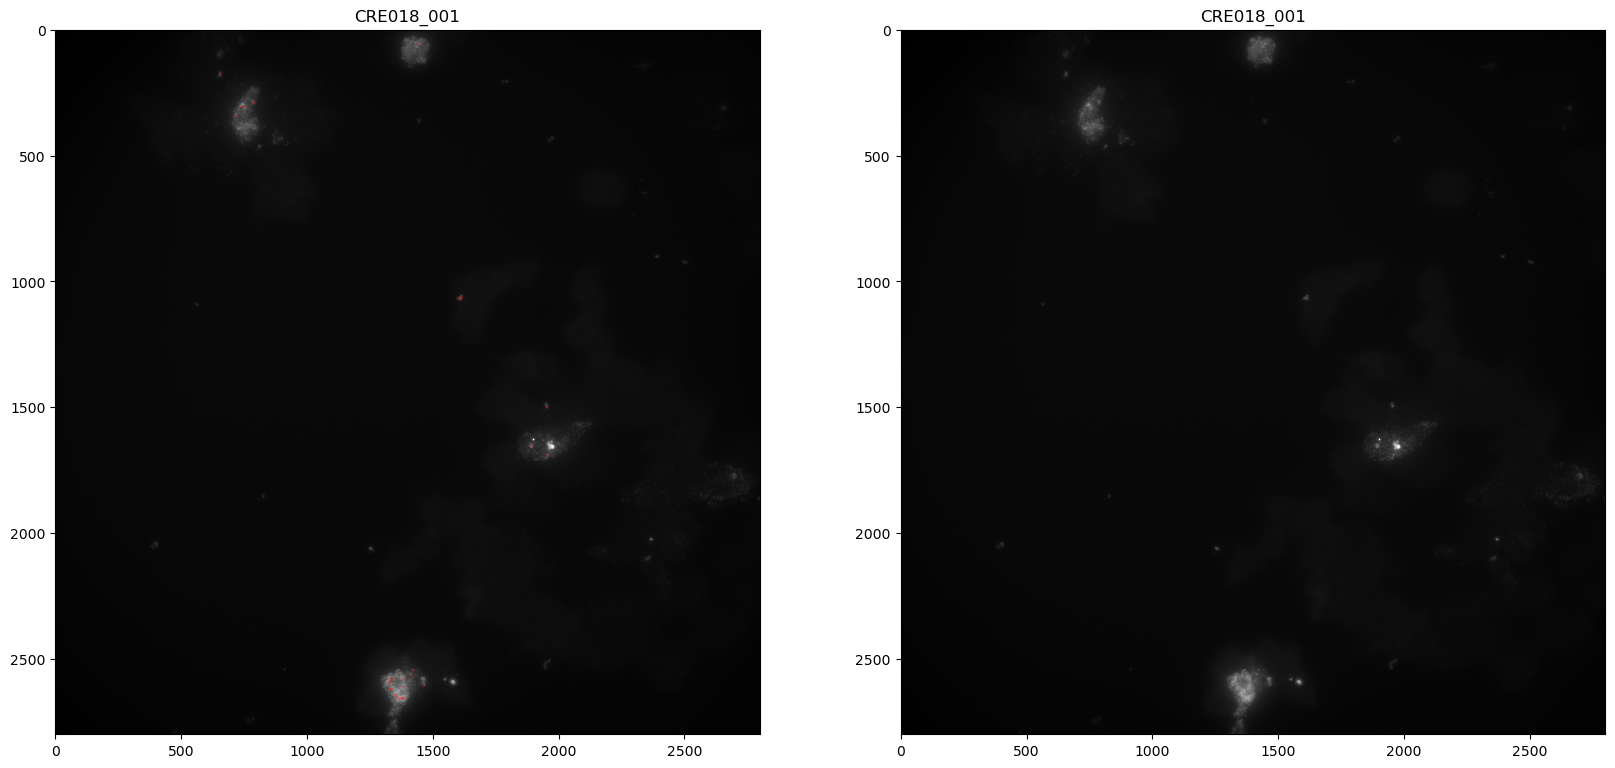

In [75]:
import matplotlib.pyplot as plt

CRE018_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__050--H6_fits_icol2.npz')['Xh']
h = CRE018_001[:,7]
keep = np.where((h>700) & (h<1000))
CRE018_001_ = CRE018_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H6/Conv_zscan__050.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[2,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].scatter(CRE018_001_[:,2], CRE018_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE018_001')

axs[1].imshow(np.max(img[2,:,:], axis=0), vmax=5000, cmap='gray')
axs[1].set_title('CRE018_001')
# plt.gca().invert_yaxis()

Text(0.5, 1.0, 'CRE019_001')

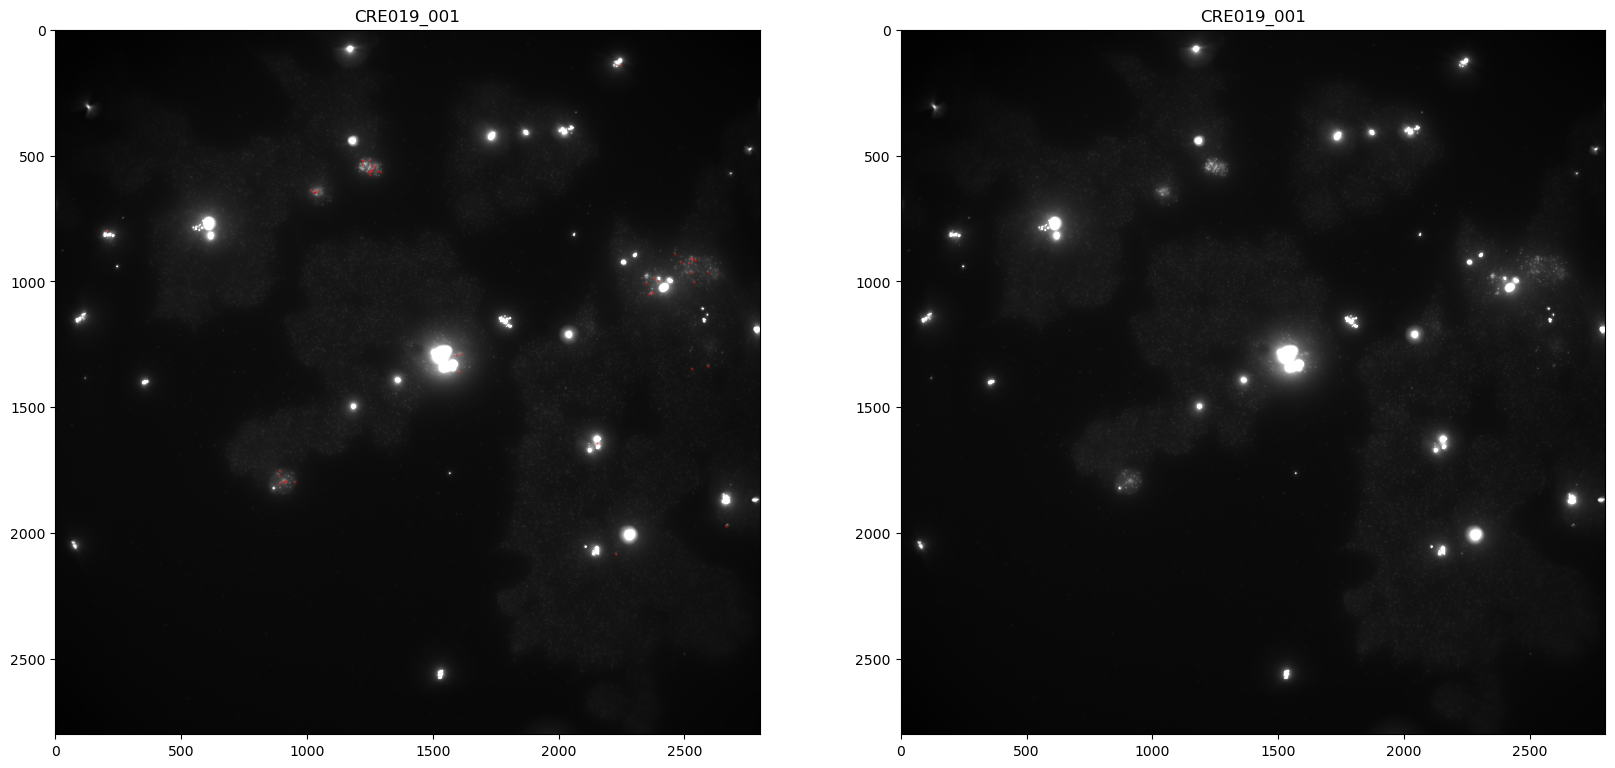

In [76]:
import matplotlib.pyplot as plt

CRE019_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__049--H7_fits_icol0.npz')['Xh']
h = CRE019_001[:,7]
keep = np.where((h>700) & (h<1000))
CRE019_001_ = CRE019_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H7/Conv_zscan__049.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[0,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].scatter(CRE019_001_[:,2], CRE019_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE019_001')

axs[1].imshow(np.max(img[0,:,:], axis=0), vmax=5000, cmap='gray')
axs[1].set_title('CRE019_001')
# plt.gca().invert_yaxis()

Text(0.5, 1.0, 'CRE020_001')

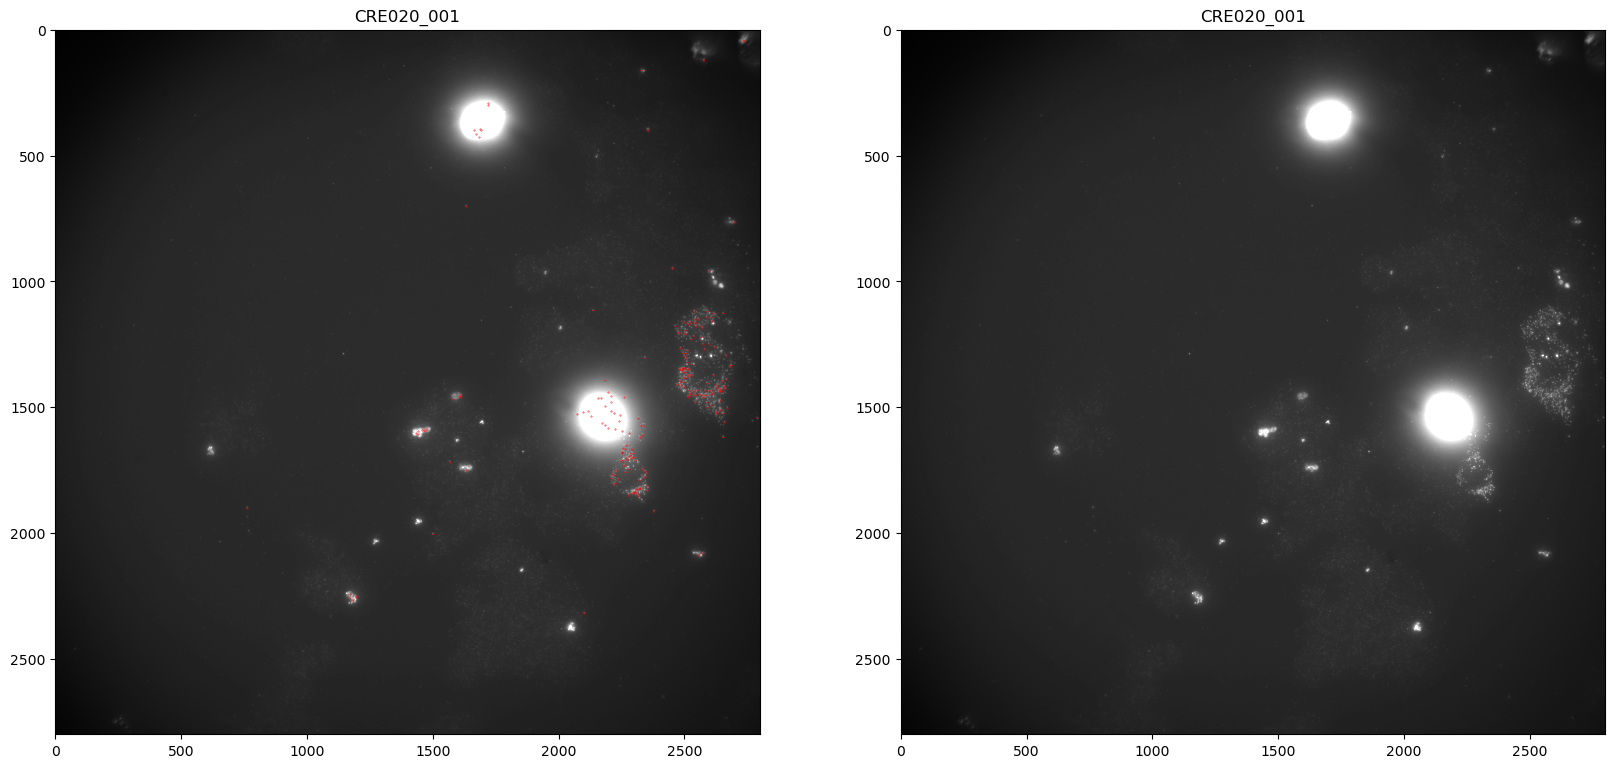

In [51]:
import matplotlib.pyplot as plt

CRE020_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__001--H7_fits_icol1.npz')['Xh']
h = CRE020_001[:,7]
keep = np.where((h>700) & (h<1000))
CRE020_001_ = CRE020_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H7/Conv_zscan__001.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[1,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].scatter(CRE020_001_[:,2], CRE020_001_[:,1], s=0.1, c='r')
axs[0].set_title('CRE020_001')

axs[1].imshow(np.max(img[1,:,:], axis=0), vmax=5000, cmap='gray')
axs[1].set_title('CRE020_001')
# plt.gca().invert_yaxis()

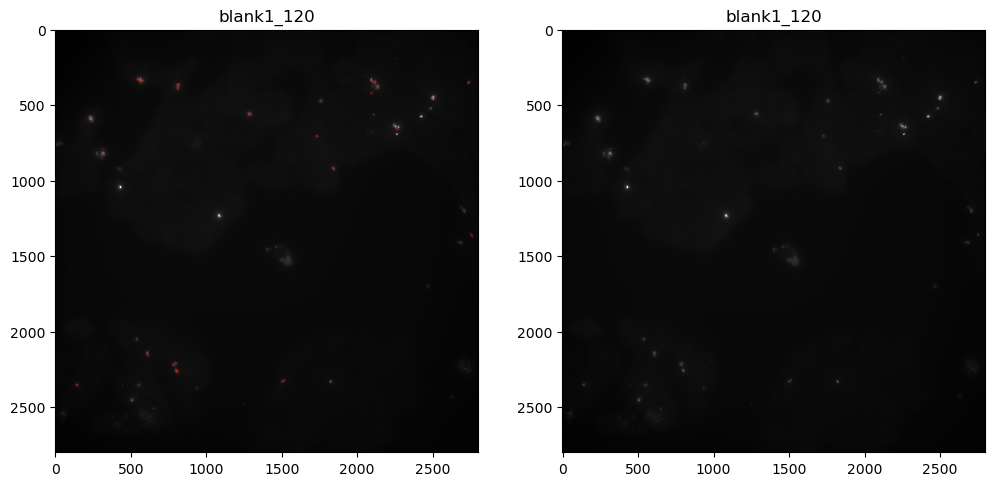

In [27]:
import matplotlib.pyplot as plt

CRE020_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__120--H7_fits_icol2.npz')['Xh']
h = CRE020_001[:,7]
keep = np.where((h>700) & (h<1000))
CRE020_001_ = CRE020_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H7/Conv_zscan__120.zarr')

fig, axs = plt.subplots(1, 2, figsize=(12,6))

axs[0].imshow(np.max(img[2,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].scatter(CRE020_001_[:,2], CRE020_001_[:,1], s=0.1, c='r')
axs[0].set_title('blank1_120')

axs[1].imshow(np.max(img[2,:,:], axis=0), vmax=5000, cmap='gray')
axs[1].set_title('blank1_120')
# plt.gca().invert_yaxis()

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/blank1_120_filtered_spots.png', dpi=450)

Text(0.5, 1.0, 'blank2')

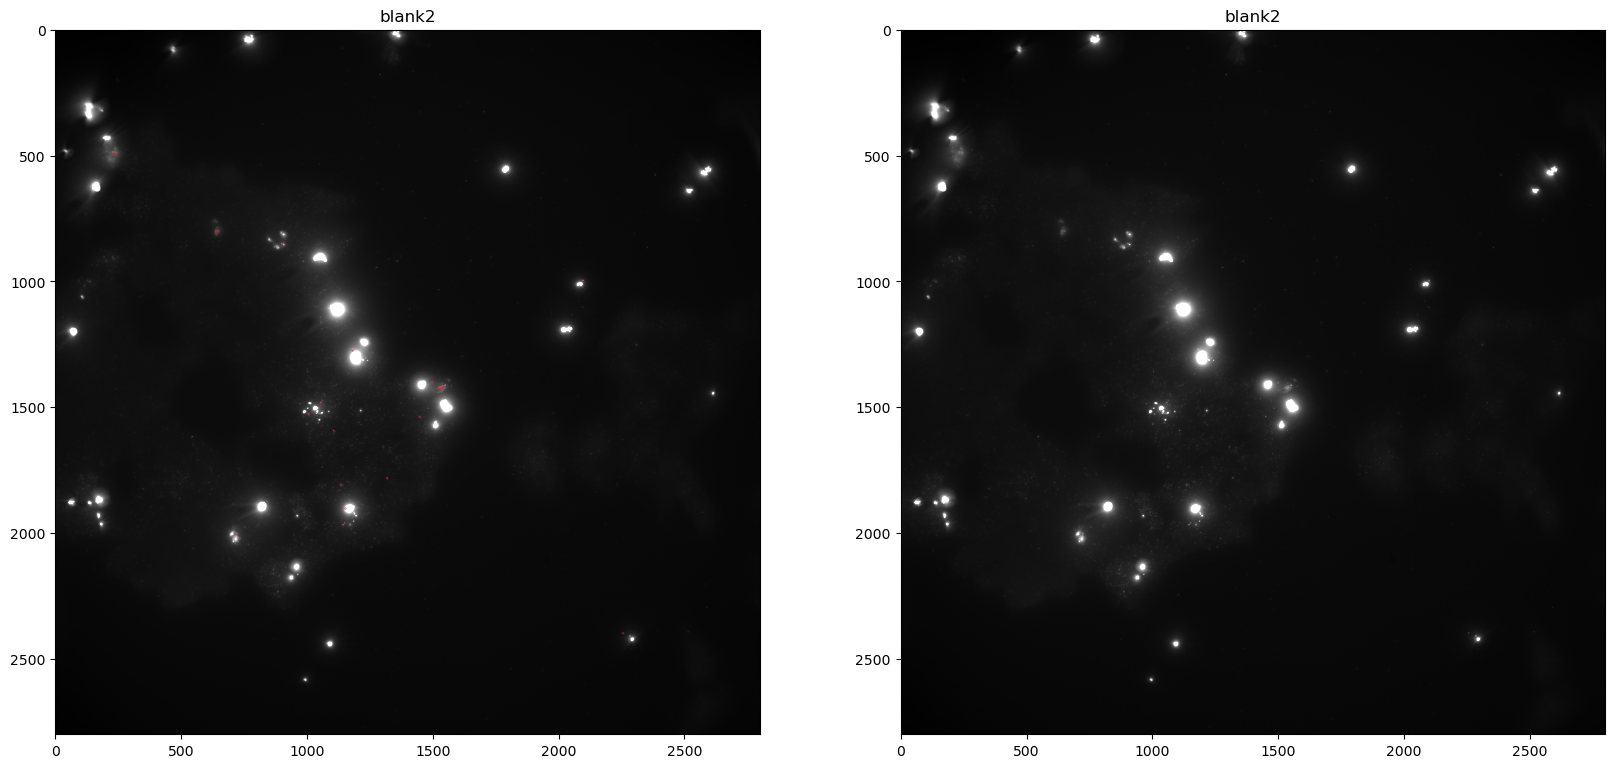

In [80]:
import matplotlib.pyplot as plt

CRE020_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__051--H8_fits_icol0.npz')['Xh']
h = CRE020_001[:,7]
keep = np.where((h>700) & (h<1000))
CRE020_001_ = CRE020_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H8/Conv_zscan__051.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[0,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].scatter(CRE020_001_[:,2], CRE020_001_[:,1], s=0.1, c='r')
axs[0].set_title('blank2')

axs[1].imshow(np.max(img[0,:,:], axis=0), vmax=5000, cmap='gray')
axs[1].set_title('blank2')
# plt.gca().invert_yaxis()

Text(0.5, 1.0, 'blank3')

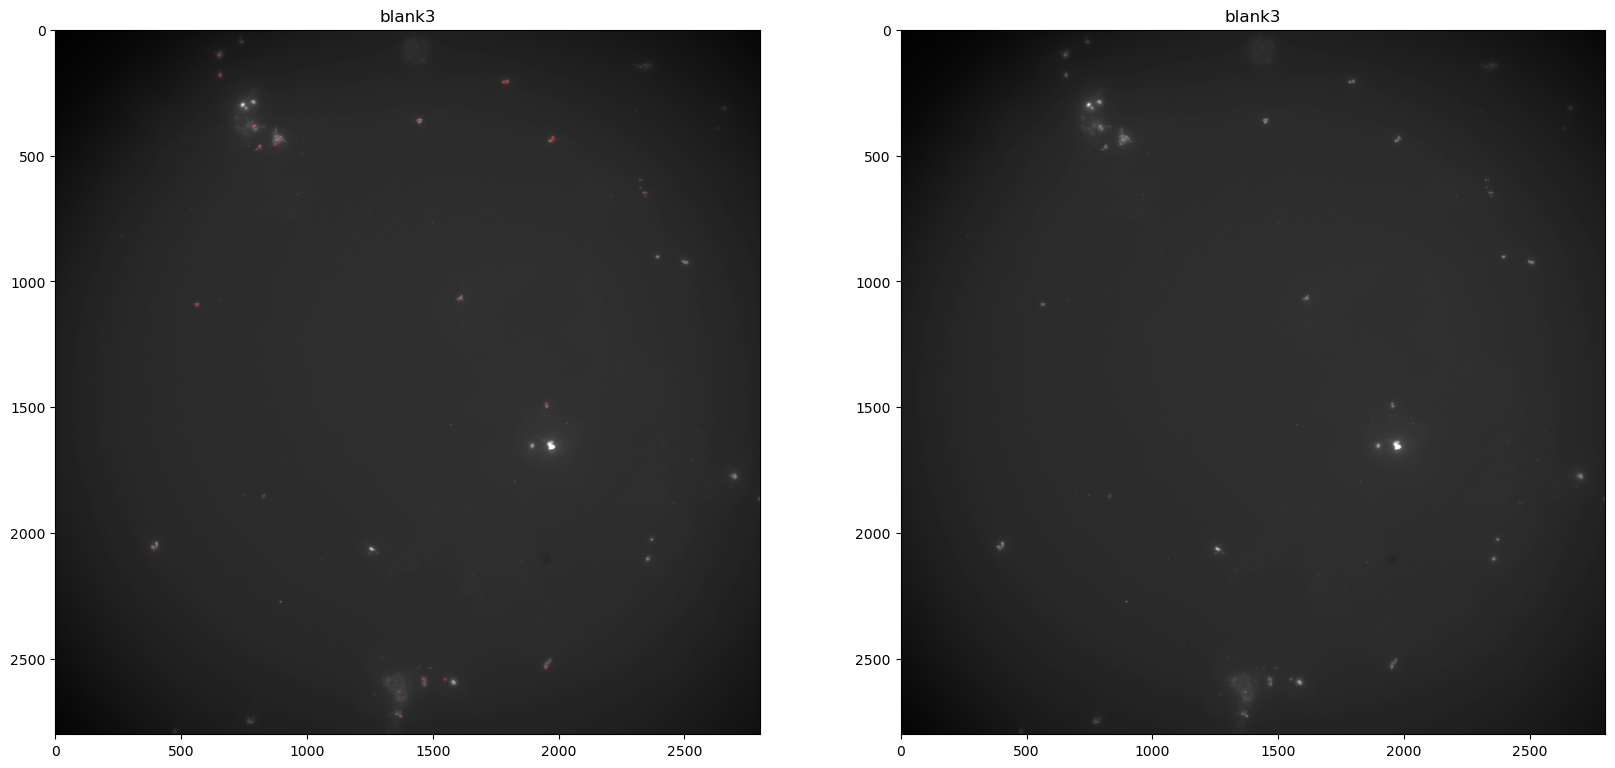

In [82]:
import matplotlib.pyplot as plt

CRE020_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__050--H8_fits_icol1.npz')['Xh']
h = CRE020_001[:,7]
keep = np.where((h>700) & (h<1000))
CRE020_001_ = CRE020_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H8/Conv_zscan__050.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[1,:,:], axis=0), vmax=5000, cmap='gray')
axs[0].scatter(CRE020_001_[:,2], CRE020_001_[:,1], s=0.1, c='r')
axs[0].set_title('blank3')

axs[1].imshow(np.max(img[1,:,:], axis=0), vmax=5000, cmap='gray')
axs[1].set_title('blank3')
# plt.gca().invert_yaxis()

Text(0.5, 1.0, 'blank4')

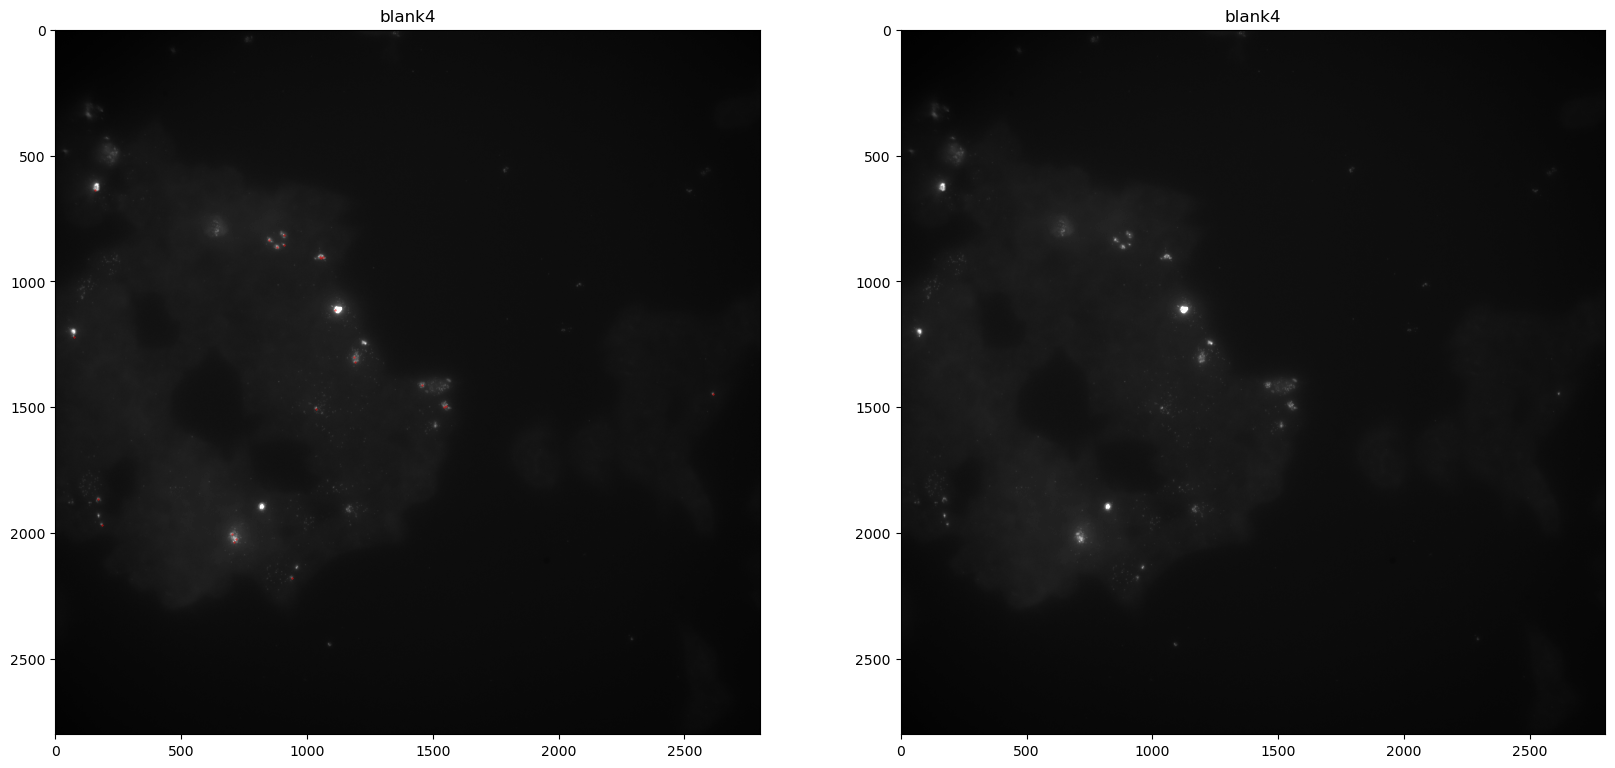

In [86]:
import matplotlib.pyplot as plt

CRE020_001 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__051--H8_fits_icol2.npz')['Xh']
h = CRE020_001[:,7]
keep = np.where((h>600) & (h<1000))
CRE020_001_ = CRE020_001[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H8/Conv_zscan__051.zarr')

fig, axs = plt.subplots(1, 2, figsize=(20,20))

axs[0].imshow(np.max(img[2,:,:], axis=0), vmax=3000, cmap='gray')
axs[0].scatter(CRE020_001_[:,2], CRE020_001_[:,1], s=0.1, c='r')
axs[0].set_title('blank4')

axs[1].imshow(np.max(img[2,:,:], axis=0), vmax=3000, cmap='gray')
axs[1].set_title('blank4')
# plt.gca().invert_yaxis()

In [155]:
CRE001 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H1_fits_icol0.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE001.extend(spots_)
CRE001 = np.array(CRE001)

100%|██████████| 20/20 [00:00<00:00, 72.22it/s]


In [156]:
CRE001.shape

(13849, 8)

In [157]:
CRE002 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H1_fits_icol1.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE002.extend(spots_)
CRE002 = np.array(CRE002)

100%|██████████| 20/20 [00:00<00:00, 53.64it/s]


In [158]:
CRE002.shape

(22839, 8)

In [159]:
CRE003 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H1_fits_icol2.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE003.extend(spots_)
CRE003 = np.array(CRE003)

100%|██████████| 20/20 [00:00<00:00, 139.47it/s]


In [160]:
CRE003.shape

(15285, 8)

In [161]:
CRE004 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H2_fits_icol0.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE004.extend(spots_)
CRE004 = np.array(CRE004)

100%|██████████| 20/20 [00:00<00:00, 64.39it/s]


In [162]:
CRE004.shape

(9302, 8)

In [163]:
CRE005 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H2_fits_icol1.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE005.extend(spots_)
CRE005 = np.array(CRE005)

100%|██████████| 20/20 [00:00<00:00, 35.39it/s]


In [164]:
CRE005.shape

(158988, 8)

In [165]:
CRE006 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H2_fits_icol2.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE006.extend(spots_)
CRE006 = np.array(CRE006)

100%|██████████| 20/20 [00:00<00:00, 131.13it/s]


In [166]:
CRE006.shape

(2114, 8)

In [167]:
CRE007 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H3_fits_icol0.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE007.extend(spots_)
CRE007 = np.array(CRE007)

100%|██████████| 20/20 [00:00<00:00, 83.94it/s]


In [168]:
CRE007.shape

(8088, 8)

In [169]:
CRE008 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H3_fits_icol1.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE008.extend(spots_)
CRE008 = np.array(CRE008)

100%|██████████| 20/20 [00:00<00:00, 76.13it/s]


In [170]:
CRE008.shape

(10157, 8)

In [171]:
CRE009 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H3_fits_icol2.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE009.extend(spots_)
CRE009 = np.array(CRE009)

100%|██████████| 20/20 [00:00<00:00, 194.75it/s]


In [172]:
CRE009.shape

(1474, 8)

In [173]:
CRE010 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H4_fits_icol0.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE010.extend(spots_)
CRE010 = np.array(CRE010)

100%|██████████| 20/20 [00:00<00:00, 81.12it/s]


In [174]:
CRE010.shape

(3548, 8)

In [175]:
CRE011 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H4_fits_icol1.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE011.extend(spots_)
CRE011 = np.array(CRE011)

100%|██████████| 20/20 [00:00<00:00, 104.88it/s]


In [176]:
CRE011.shape

(1282, 8)

In [177]:
CRE012 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H4_fits_icol2.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE012.extend(spots_)
CRE012 = np.array(CRE012)

100%|██████████| 20/20 [00:00<00:00, 232.48it/s]


In [178]:
CRE012.shape

(1175, 8)

In [179]:
CRE013 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H5_fits_icol0.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE013.extend(spots_)
CRE013 = np.array(CRE013)

100%|██████████| 20/20 [00:00<00:00, 72.86it/s]


In [180]:
CRE013.shape

(8884, 8)

In [181]:
CRE014 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H5_fits_icol1.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE014.extend(spots_)
CRE014 = np.array(CRE014)

100%|██████████| 20/20 [00:00<00:00, 71.66it/s]


In [182]:
CRE014.shape

(2493, 8)

In [183]:
CRE015 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H5_fits_icol2.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE015.extend(spots_)
CRE015 = np.array(CRE015)

100%|██████████| 20/20 [00:00<00:00, 150.68it/s]


In [184]:
CRE015.shape

(1135, 8)

In [185]:
CRE016 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H6_fits_icol0.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE016.extend(spots_)
CRE016 = np.array(CRE016)

100%|██████████| 20/20 [00:00<00:00, 89.91it/s]


In [186]:
CRE016.shape

(2522, 8)

In [187]:
CRE017 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H6_fits_icol1.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE017.extend(spots_)
CRE017 = np.array(CRE017)

100%|██████████| 20/20 [00:00<00:00, 98.12it/s]


In [188]:
CRE017.shape

(7207, 8)

In [189]:
CRE018 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H6_fits_icol2.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE018.extend(spots_)
CRE018 = np.array(CRE018)

100%|██████████| 20/20 [00:00<00:00, 180.04it/s]


In [190]:
CRE018.shape

(2350, 8)

In [191]:
CRE019 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H7_fits_icol0.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE019.extend(spots_)
CRE019 = np.array(CRE019)

100%|██████████| 20/20 [00:00<00:00, 85.62it/s]


In [192]:
CRE019.shape

(2243, 8)

In [193]:
CRE020 = []

for fov in tqdm(range(20)):
    spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H7_fits_icol1.npz')['Xh']
    h = spots[:,7]
    keep = np.where((h>450) & (h<1000))
    spots_ = spots[keep]
    CRE020.extend(spots_)
CRE020 = np.array(CRE020)

100%|██████████| 20/20 [00:00<00:00, 79.53it/s]


In [194]:
CRE020.shape

(14043, 8)

### Plot cell centers and/or spots with the segmentation masks

In [199]:
import numpy as np
import pandas as pd

seg_masks004 = np.load('/projects/ps-renlab2/zgibbs/cellpose/8_23_2023__CRE-20_10XCREConc/polyA_slice20/Conv_zscan__004_seg.npy', allow_pickle=True)[()]

Text(0.5, 1.0, 'CRE002_004')

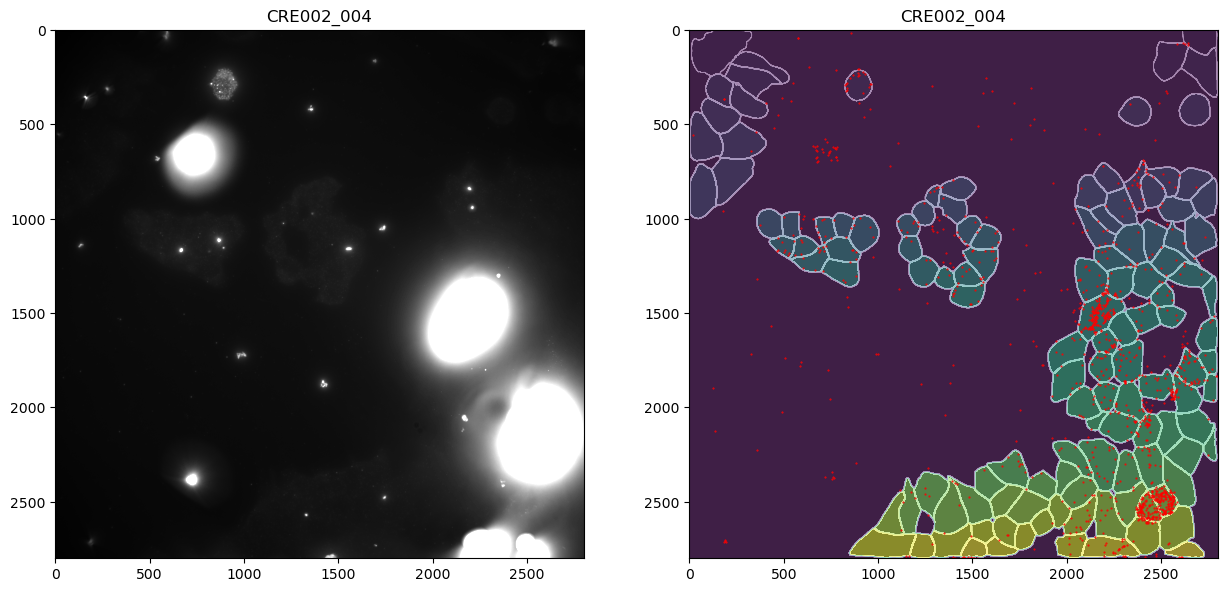

In [201]:
import matplotlib.pyplot as plt

CRE002_004 = np.load('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__004--H1_fits_icol1.npz')['Xh']
h = CRE002_004[:,7]
keep = np.where((h>400) & (h<800))
CRE002_004_ = CRE002_004[keep]

img = read_im('/oasis/tscc/scratch/zgibbs/8_23_2023__CRE-20_10XCREConc/H1/Conv_zscan__004.zarr')

fig, axs = plt.subplots(1, 2, figsize=(15,10))

axs[0].imshow(np.max(img[0,:,:], axis=0), vmax=10000, cmap='gray')
axs[0].set_title('CRE002_004')

axs[1].imshow(seg_masks004['masks'], cmap = 'viridis', alpha=0.8)
axs[1].imshow(seg_masks004['outlines'], cmap = 'binary_r', alpha=0.4, vmax=0.1)
axs[1].scatter(CRE002_004_[:,2], CRE002_004_[:,1], s=0.25, c='r')
axs[1].set_title('CRE002_004')
# plt.scatter(df['x'], df['y'], color='k', s=5) # cell centers
# plt.scatter(y, x, color='r', s=1, alpha=0.5) # YFP spots

In [195]:
counts = (len(CRE001), len(CRE002), len(CRE003), len(CRE004), len(CRE005), len(CRE006), len(CRE007), len(CRE008), len(CRE009), len(CRE010), len(CRE011), len(CRE012), len(CRE013), len(CRE014), len(CRE015), len(CRE016), len(CRE017), len(CRE018), len(CRE019), len(CRE020))

In [122]:
counts

[23506,
 17131,
 71791,
 15680,
 66086,
 13775,
 12554,
 8853,
 10161,
 5204,
 1113,
 7188,
 14327,
 1995,
 7926,
 3844,
 5625,
 16505,
 3420,
 12158]

<BarContainer object of 20 artists>

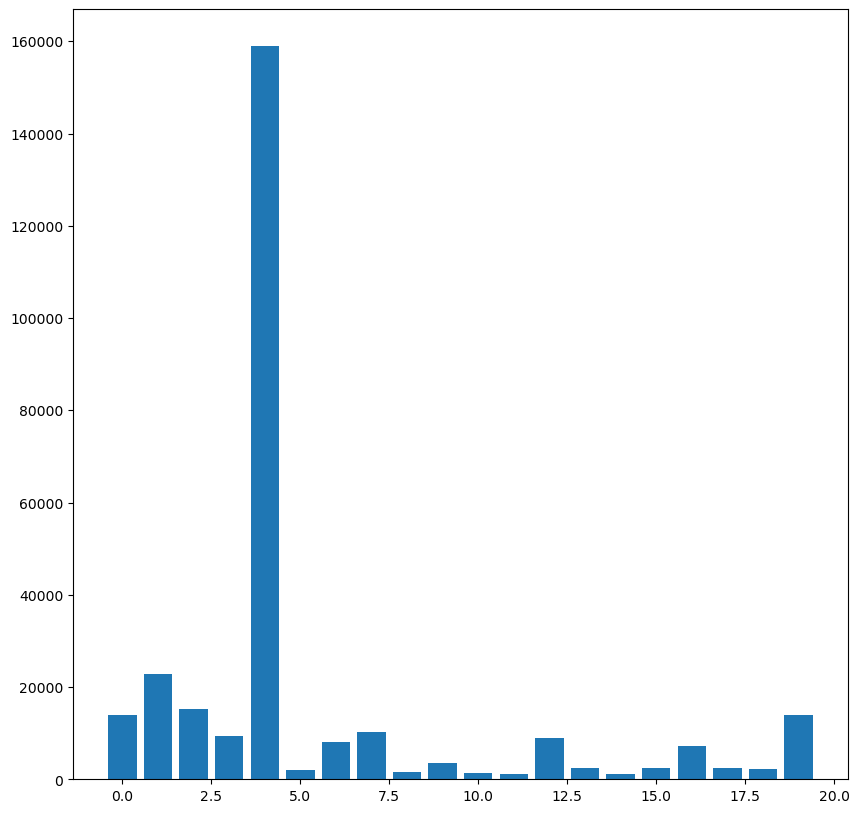

In [196]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

CREs = ('CRE001, CRE002, CRE003, CRE004, CRE005, CRE006, CRE007, CRE008, CRE009, CRE010, CRE011, CRE012, CRE013, CRE014, CRE015, CRE016, CRE017, CRE018, CRE019, CRE020')

ax.bar(range(20), counts)

In [116]:
len(CRE020)

12158

## Try to assign spots to masks

In [7]:
# Make a yuge dict for all CRE spots across FOVs

CRE_counts = {}

for fov in tqdm(range(20)):
    for hybe in range(1,9):
        for icol in range(3):
            spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H{hybe:01d}_fits_icol{icol:01d}.npz')['Xh']
            h = spots[:,7]
            if icol == 0:
                keep = np.where((h>665) & (h<1800))
                spots_ = spots[keep]
                CRE_counts[f'{fov:03d}-H{hybe}-{icol}'] = spots_
            
            if icol == 1:
                keep = np.where((h>400) & (h<1800))
                spots_ = spots[keep]
                CRE_counts[f'{fov:03d}-H{hybe}-{icol}'] = spots_
                
            if icol == 2:
                keep = np.where((h>150) & (h<400))
                spots_ = spots[keep]
                CRE_counts[f'{fov:03d}-H{hybe}-{icol}'] = spots_


100%|██████████| 20/20 [00:04<00:00,  4.48it/s]


In [8]:
CRE_counts.keys()

dict_keys(['000-H1-0', '000-H1-1', '000-H1-2', '000-H2-0', '000-H2-1', '000-H2-2', '000-H3-0', '000-H3-1', '000-H3-2', '000-H4-0', '000-H4-1', '000-H4-2', '000-H5-0', '000-H5-1', '000-H5-2', '000-H6-0', '000-H6-1', '000-H6-2', '000-H7-0', '000-H7-1', '000-H7-2', '000-H8-0', '000-H8-1', '000-H8-2', '001-H1-0', '001-H1-1', '001-H1-2', '001-H2-0', '001-H2-1', '001-H2-2', '001-H3-0', '001-H3-1', '001-H3-2', '001-H4-0', '001-H4-1', '001-H4-2', '001-H5-0', '001-H5-1', '001-H5-2', '001-H6-0', '001-H6-1', '001-H6-2', '001-H7-0', '001-H7-1', '001-H7-2', '001-H8-0', '001-H8-1', '001-H8-2', '002-H1-0', '002-H1-1', '002-H1-2', '002-H2-0', '002-H2-1', '002-H2-2', '002-H3-0', '002-H3-1', '002-H3-2', '002-H4-0', '002-H4-1', '002-H4-2', '002-H5-0', '002-H5-1', '002-H5-2', '002-H6-0', '002-H6-1', '002-H6-2', '002-H7-0', '002-H7-1', '002-H7-2', '002-H8-0', '002-H8-1', '002-H8-2', '003-H1-0', '003-H1-1', '003-H1-2', '003-H2-0', '003-H2-1', '003-H2-2', '003-H3-0', '003-H3-1', '003-H3-2', '003-H4-0', '003-

In [27]:
CRE_counts['019-H1-0'].shape

(427, 8)

In [11]:
CREs = ('CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020', 'blank1', 'blank2', 'blank3', 'blank4')


In [12]:
fov = 12
fov_filter = [f'{fov:03d}-H1-0', f'{fov:03d}-H1-1', f'{fov:03d}-H1-2', f'{fov:03d}-H2-0', f'{fov:03d}-H2-1', f'{fov:03d}-H2-2', f'{fov:03d}-H3-0', f'{fov:03d}-H3-1', f'{fov:03d}-H3-2', f'{fov:03d}-H4-0',
              f'{fov:03d}-H4-1', f'{fov:03d}-H4-2', f'{fov:03d}-H5-0', f'{fov:03d}-H5-1', f'{fov:03d}-H5-2', f'{fov:03d}-H6-0', f'{fov:03d}-H6-1', f'{fov:03d}-H6-2', f'{fov:03d}-H7-0', f'{fov:03d}-H7-1',
              f'{fov:03d}-H7-2', f'{fov:03d}-H8-0', f'{fov:03d}-H8-1', f'{fov:03d}-H8-2']
ccre_conversion = { channel_id[3:] : ccre for channel_id, ccre in zip(fov_filter, CREs)}

filterByKey = lambda keys: {ccre_conversion[x[3:]] : CRE_counts[x] for x in keys}

CRE_counts_000 = filterByKey(fov_filter)

In [13]:
fov_counts =[]
for fov in tqdm(range(20)):
    fov_filter = [f'{fov:03d}-H1-0', f'{fov:03d}-H1-1', f'{fov:03d}-H1-2', f'{fov:03d}-H2-0', f'{fov:03d}-H2-1', f'{fov:03d}-H2-2', f'{fov:03d}-H3-0', f'{fov:03d}-H3-1', f'{fov:03d}-H3-2', f'{fov:03d}-H4-0',
              f'{fov:03d}-H4-1', f'{fov:03d}-H4-2', f'{fov:03d}-H5-0', f'{fov:03d}-H5-1', f'{fov:03d}-H5-2', f'{fov:03d}-H6-0', f'{fov:03d}-H6-1', f'{fov:03d}-H6-2', f'{fov:03d}-H7-0', f'{fov:03d}-H7-1',
              f'{fov:03d}-H7-2', f'{fov:03d}-H8-0', f'{fov:03d}-H8-1', f'{fov:03d}-H8-2']
    fov_counts.append(filterByKey(fov_filter))

100%|██████████| 20/20 [00:00<00:00, 20671.78it/s]


In [137]:
fov_counts[0].keys()

dict_keys(['CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008', 'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016', 'CRE017', 'CRE018', 'CRE019', 'CRE020', 'blank1', 'blank2', 'blank3', 'blank4'])

In [14]:
fov_counts[0]['CRE001']

array([[5.84200515e+00, 1.79589719e+03, 1.20806605e+03, ...,
        9.54910930e+03, 7.22970818e-01, 9.04268555e+02],
       [6.06876663e+00, 1.79906623e+03, 1.22186650e+03, ...,
        1.04759500e+04, 8.30672557e-01, 1.20821387e+03],
       [6.21765248e+00, 1.83997237e+03, 3.12017159e+02, ...,
        1.58406424e+03, 8.24573243e-01, 1.05619360e+03],
       ...,
       [4.77895685e+01, 1.73189265e+03, 1.95908277e+03, ...,
        1.61730526e+04, 6.26680903e-01, 7.48433594e+02],
       [4.75650331e+01, 1.77315167e+03, 1.18711235e+03, ...,
        7.73453809e+03, 5.63755069e-01, 8.57453613e+02],
       [4.76021037e+01, 1.77479270e+03, 1.18203741e+03, ...,
        7.05036940e+03, 6.56917738e-01, 9.23079102e+02]])

In [151]:
seg_mask['masks']

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint16)

In [156]:
barcodes

,masks,cre_id,x_round,y_round
0,"[51, 51, 0, 0, 90, 0, 44, 44, 0, 51, 49, 51, 5...","[CRE001, CRE001, CRE001, CRE001, CRE001, CRE00...","[1208.0, 1222.0, 312.0, 505.0, 1307.0, 150.0, ...","[1796.0, 1799.0, 1840.0, 2213.0, 2452.0, 1593...."
1,"[5, 0, 0, 5, 5, 5, 0, 0, 0, 0, 88, 93, 0, 5, 0...","[CRE002, CRE002, CRE002, CRE002, CRE002, CRE00...","[395.0, 1963.0, 1913.0, 457.0, 304.0, 409.0, 1...","[224.0, 3.0, 4.0, 263.0, 185.0, 267.0, 4.0, 17..."
2,"[0, 0, 0, 0, 0, 5, 5, 51, 0, 0, 0, 0, 0, 5, 51...","[CRE003, CRE003, CRE003, CRE003, CRE003, CRE00...","[49.0, 52.0, 105.0, 92.0, 78.0, 388.0, 360.0, ...","[15.0, 21.0, 29.0, 37.0, 66.0, 231.0, 234.0, 1..."
3,"[103, 44, 51, 0, 75, 0, 0, 0, 0, 44, 44, 0, 44...","[CRE004, CRE004, CRE004, CRE004, CRE004, CRE00...","[1163.0, 1809.0, 1203.0, 1886.0, 933.0, 64.0, ...","[2704.0, 1646.0, 1789.0, 1877.0, 2229.0, 1234...."
4,"[0, 0, 76, 80, 100, 100, 97, 97, 106, 106, 104...","[CRE005, CRE005, CRE005, CRE005, CRE005, CRE00...","[408.0, 243.0, 1147.0, 1376.0, 1284.0, 1316.0,...","[2073.0, 2147.0, 2297.0, 2417.0, 2574.0, 2599...."
5,"[0, 0, 94, 100, 0, 103, 106, 104, 0, 69, 73, 7...","[CRE006, CRE006, CRE006, CRE006, CRE006, CRE00...","[706.0, 794.0, 1018.0, 1311.0, 1519.0, 1154.0,...","[2766.0, 2793.0, 2581.0, 2618.0, 2711.0, 2721...."
6,"[103, 44, 0, 0, 0, 44, 44, 5, 5, 5, 5, 19, 0, ...","[CRE007, CRE007, CRE007, CRE007, CRE007, CRE00...","[1164.0, 1810.0, 468.0, 1668.0, 1846.0, 1759.0...","[2711.0, 1653.0, 306.0, 560.0, 753.0, 1684.0, ..."
7,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, ...","[CRE008, CRE008, CRE008, CRE008, CRE008, CRE00...","[1477.0, 301.0, 14.0, 49.0, 1756.0, 1803.0, 11...","[2488.0, 1477.0, 1222.0, 1250.0, 1725.0, 1755...."
8,"[73, 71, 0, 79, 76, 80, 80, 80, 80, 92, 103, 4...","[CRE009, CRE009, CRE009, CRE009, CRE009, CRE00...","[1505.0, 1392.0, 1393.0, 1550.0, 1145.0, 1353....","[2199.0, 2215.0, 2277.0, 2279.0, 2291.0, 2337...."
9,"[103, 44, 19, 0, 0, 0, 5, 51, 44, 40, 51, 49, ...","[CRE010, CRE010, CRE010, CRE010, CRE010, CRE01...","[1163.0, 1809.0, 1734.0, 1667.0, 2349.0, 1680....","[2705.0, 1647.0, 463.0, 554.0, 1089.0, 553.0, ..."


In [174]:
[spot_masks[1][i].shape for i in range(4)]

[(1104,), (1104,), (1104,), (1104,)]

In [220]:
import pandas as pd
import numpy as np

masked_spots = []
all_cbg = []
for fov in range(20):
    # load cellpose masks and add (FOV x 1000) to the mask values to distinguish them from other FOVs
    seg_mask = np.load(f'/projects/ps-renlab2/zgibbs/cellpose/8_23_2023__CRE-20_10XCREConc/polyA_slice20/Conv_zscan__{fov:03d}_seg.npy', allow_pickle=True)[()]
    mask_id = fov * 1000
    seg_mask['masks'] = seg_mask['masks'] + mask_id 

    # specify the appropriate FOV for spots
    spots = fov_counts[fov]
    
    # round the x,y coordinates for decoded spots and assign to the masks from cellpose
    spot_masks = []
    for key in spots.keys():
        spots[key][:,2] = np.around(spots[key][:,2])
        spots[key][:,1] = np.around(spots[key][:,1])
        masks = seg_mask['masks'][np.around(spots[key][:,1]).astype(int), np.around(spots[key][:,2]).astype(int)]
        spot_masks += [np.array([masks, np.array([key] * (spots[key].shape[0])), np.around(spots[key][:,2]), np.around(spots[key][:,1])])]
        
    # masked_spots.append(spot_masks)
    # save the cell-by-gene matrix for this FOV
    spot_masks = np.hstack(spot_masks).T
    barcodes = pd.DataFrame(data=spot_masks, columns=['masks', 'cre_id', 'x_round', 'y_round'])
    cell_by_gene = pd.crosstab(barcodes.masks, barcodes.cre_id)
    all_cbg.append(cell_by_gene)
    # cell_by_gene.to_csv(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/cell_by_gene/cell_by_gene_{fov:03d}.csv')

In [221]:
import os

# merge cell-by-gene matrix from each FOV and write to new csv file
file_path = '/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/cell_by_gene/'
file_list = os.listdir(file_path)

os.chdir('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/cell_by_gene/')

cell_by_gene_total = pd.concat([pd.read_csv(f) for f in file_list])
cell_by_gene_total.to_csv('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/cell_by_gene/cell_by_gene_total.csv', index=False)

In [182]:
pd.concat(all_cbg, axis=0)

cre_id,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,CRE010,...,CRE015,CRE016,CRE017,CRE018,CRE019,CRE020,blank1,blank2,blank3,blank4
masks,,,,,,,,,,,,,,,,,,,,,
0,137,316,608,39,791,103,35,104,79,11,...,73,12,63,72,7,136,55,8,60,51
1,4,0,0,0,16,0,1,3,0,0,...,0,0,0,0,0,4,0,0,0,0
100,0,2,0,0,73,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
101,0,0,0,0,84,1,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
102,0,5,6,0,57,2,0,3,5,0,...,4,0,4,4,0,5,5,0,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19076,0,4,15,0,112,1,0,0,0,1,...,1,0,0,1,0,0,0,0,0,0
19077,0,6,17,0,106,3,0,0,2,0,...,1,0,0,1,0,1,0,0,0,0
19078,2,1,1,1,142,0,1,0,0,1,...,0,1,0,1,1,0,0,1,1,0


In [204]:
all_cbg[0['CRE003'].sum()

TypeError: list indices must be integers or slices, not str

In [217]:
CRE001_spots = []

for fov in range(20):
    spots = all_cbg[fov]['CRE001'].sum()
    CRE001_spots.append(spots)

In [218]:
sum(CRE001_spots)

14576

In [139]:
fov = 3
spots = fov_counts[fov]

In [141]:
spots.keys()

dict_keys(['CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008', 'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016', 'CRE017', 'CRE018', 'CRE019', 'CRE020', 'blank1', 'blank2', 'blank3', 'blank4'])

In [144]:
spots['CRE001'][:,2] = np.around(spots['CRE001'][:,2])
spots['CRE001'][:,1] = np.around(spots['CRE001'][:,1])

In [145]:
spots['CRE001'][:,2]

array([469., 446., 449., ..., 591., 660., 641.])

In [118]:
CRE_counts_000['012-H1-0'].shape

(488, 8)

In [107]:
CRE_counts_000.keys()

dict_keys(['012-H1-0', '012-H1-1', '012-H1-2', '012-H2-0', '012-H2-1', '012-H2-2', '012-H3-0', '012-H3-1', '012-H3-2', '012-H4-0', '012-H4-1', '012-H4-2', '012-H5-0', '012-H5-1', '012-H5-2', '012-H6-0', '012-H6-1', '012-H6-2', '012-H7-0', '012-H7-1', '012-H7-2', '012-H8-0', '012-H8-1', '012-H8-2'])

In [109]:
ids = []
for id_ in range(200):
    ids.append(id_)

In [112]:
ids = [id_ for id_ in range(200)]

In [113]:
ccre_to_spot_name = {ccre : spot_name for spot_name, ccre in zip(list(CRE_counts.keys())[-24:], CREs)}

In [114]:
ccre_to_spot_name 

{'CRE001': '019-H1-0',
 'CRE002': '019-H1-1',
 'CRE003': '019-H1-2',
 'CRE004': '019-H2-0',
 'CRE005': '019-H2-1',
 'CRE006': '019-H2-2',
 'CRE007': '019-H3-0',
 'CRE008': '019-H3-1',
 'CRE009': '019-H3-2',
 'CRE010': '019-H4-0',
 'CRE011': '019-H4-1',
 'CRE012': '019-H4-2',
 'CRE013': '019-H5-0',
 'CRE014': '019-H5-1',
 'CRE015': '019-H5-2',
 'CRE016': '019-H6-0',
 'CRE017': '019-H6-1',
 'CRE018': '019-H6-2',
 'CRE019': '019-H7-0',
 'CRE020': '019-H7-1',
 'blank1': '019-H7-2',
 'blank2': '019-H8-0',
 'blank3': '019-H8-1',
 'blank4': '019-H8-2'}

In [37]:
CRE_counts_019['019-H1-0'][:,2] = np.around(CRE_counts_019['019-H1-0'][:,2])
CRE_counts_019['019-H1-0'][:,1] = np.around(CRE_counts_019['019-H1-0'][:,1])
CRE_counts_019['masks'] = seg_masks['masks'][int(CRE_counts_019['019-H1-0'][:,2]), int(CRE_counts_019['019-H1-0'][:,1])]

TypeError: only size-1 arrays can be converted to Python scalars

In [35]:
CRE_counts_019['019-H1-0'][:,] = 

array([1535., 1604., 1761., 1765., 1773., 1858., 2189., 2274., 2351.,
       2405., 1256., 1303., 1484., 2021., 2158., 2203.,  935., 1127.,
       1131., 1143., 1195., 1339., 1518., 1537., 1545., 1593., 1615.,
       1786., 1859.,  436.,  580.,  787.,  840.,  950.,  964.,  998.,
       1044., 1179., 1218., 1315., 1342., 1379., 1387., 1435., 1551.,
       1556., 1739., 1788., 2012., 2078., 2103., 2112.,  457.,  950.,
        968., 1082., 1087., 1128., 1133., 1186., 1231., 1339., 1557.,
       1580., 1590., 1622., 1639., 1669., 2022., 2068.,  954.,  956.,
        958.,  975.,  988., 1011., 1011., 1021., 1050., 1132., 1146.,
       1151., 1174., 1298., 1325., 1451., 1525., 1529., 1567., 1575.,
       1615., 1627., 1700., 1759., 1811., 1910., 2027., 2043.,  584.,
        910.,  964.,  976.,  995., 1020., 1113., 1126., 1137., 1144.,
       1170., 1212., 1307., 1347., 1365., 1383., 1416., 1495., 1527.,
       1532., 1549., 1552., 1606., 1663., 1707., 1777., 1833., 2019.,
       2105.,  971.,

In [95]:
CREs = ('CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020', 'blank1', 'blank2', 'blank3', 'blank4')

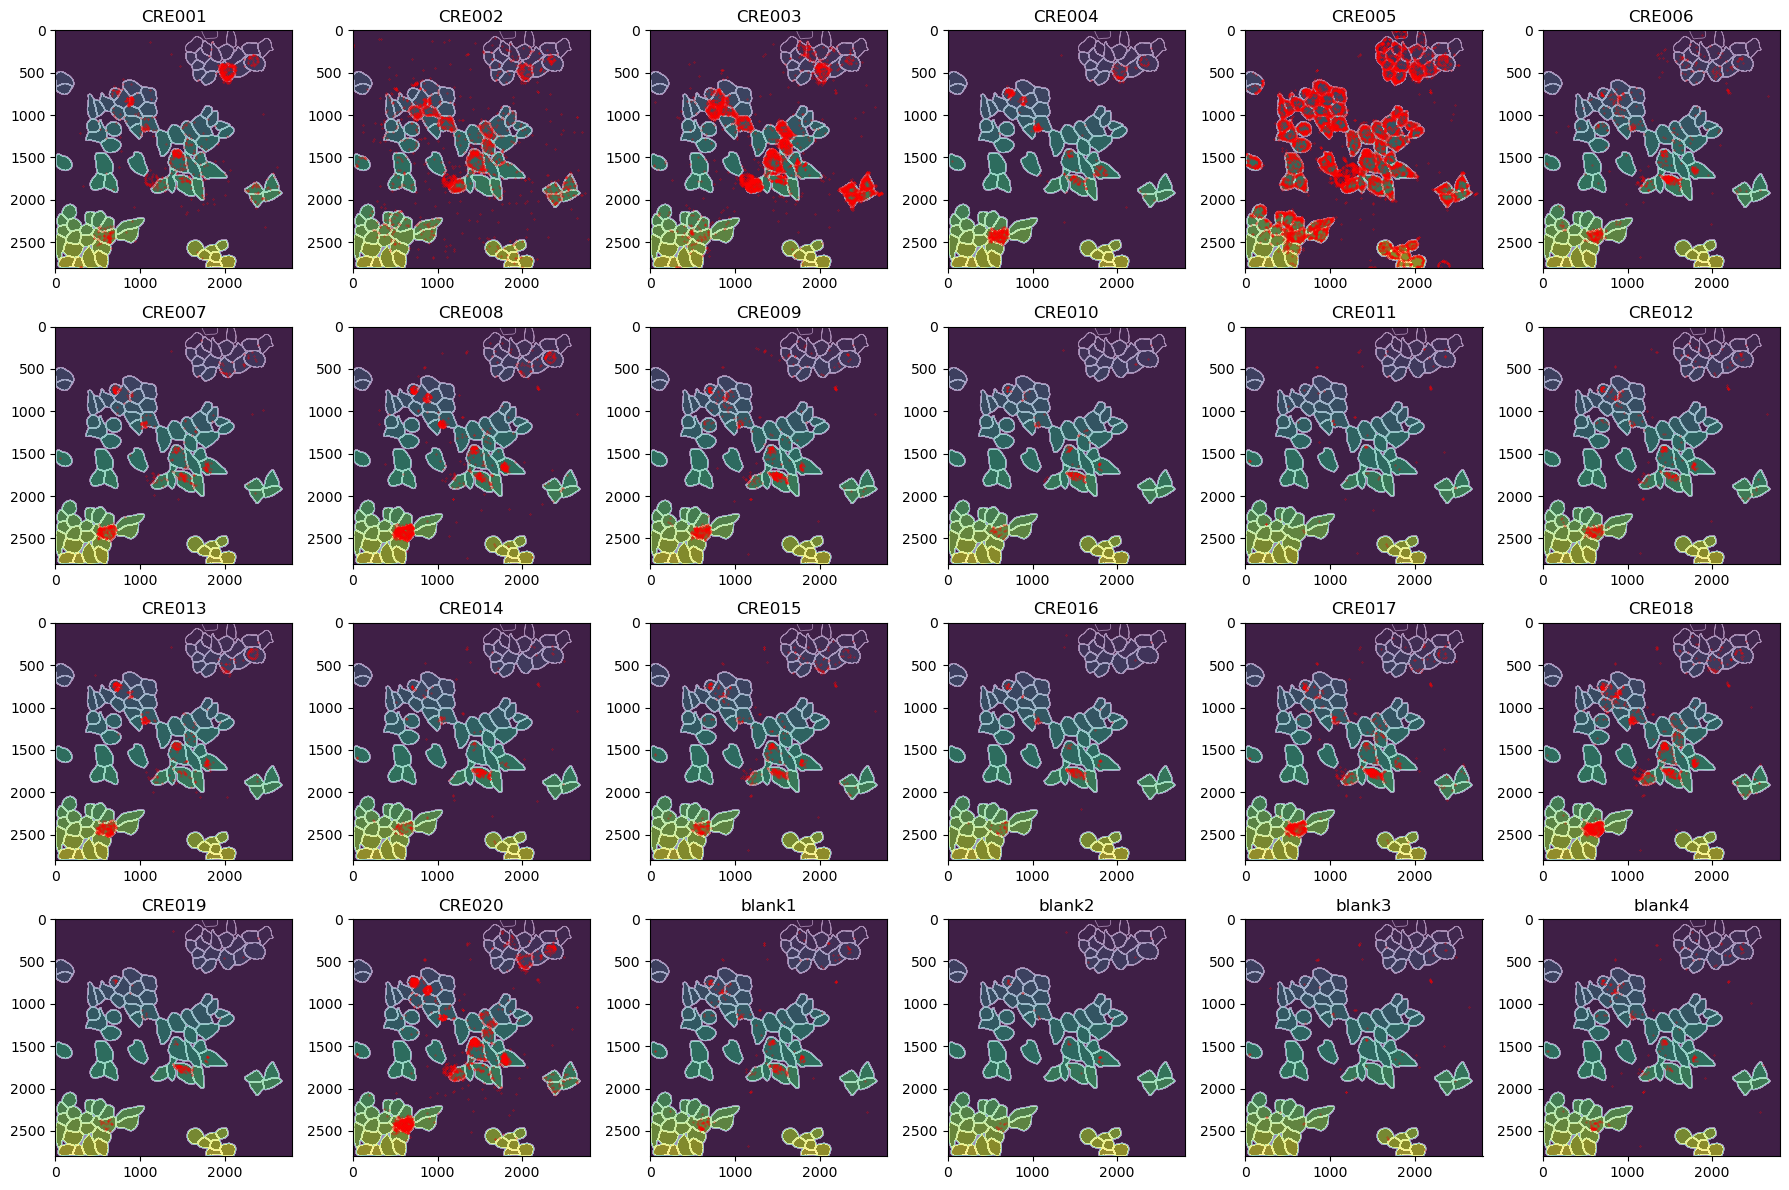

In [19]:
seg_masks = np.load('/projects/ps-renlab2/zgibbs/cellpose/8_23_2023__CRE-20_10XCREConc/polyA_slice20/Conv_zscan__002_seg.npy', allow_pickle=True)[()]

fig, axs = plt.subplots(4, 6, figsize=(18,12))

axs = axs.flatten()
for key, ax, title in zip(list(CRE_counts.keys())[48:72], axs, CREs):
    ax.imshow(seg_masks['masks'], cmap = 'viridis', alpha=0.8)
    ax.imshow(seg_masks['outlines'], cmap = 'binary_r', alpha=0.4, vmax=0.1)
    ax.scatter(CRE_counts[key][:,2], CRE_counts[key][:,1], s=0.05, c='r')
    ax.set_title(title)
    
plt.tight_layout()
# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/all_CRE_spots_masks.png', dpi=450)

In [222]:
CRE_counts = {}

for hybe in tqdm(range(1,9)):
    for icol in range(3):
        if icol == 0:
            spots_total = []
            for fov in range(20):
                spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H{hybe:01d}_fits_icol{icol:01d}.npz')['Xh']
                h = spots[:,7]
                keep = np.where((h>665) & (h<1800))
                spots_ = spots[keep]
                spots_total.extend(spots_)
            spots_total = np.array(spots_total)
        CRE_counts[f'H{hybe}-{icol}'] = spots_total
        
        if icol == 1:
            spots_total = []
            for fov in range(20):
                spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H{hybe:01d}_fits_icol{icol:01d}.npz')['Xh']
                h = spots[:,7]
                keep = np.where((h>400) & (h<1800))
                spots_ = spots[keep]
                spots_total.extend(spots_)
            spots_total = np.array(spots_total)
        CRE_counts[f'H{hybe}-{icol}'] = spots_total
        
        if icol == 2:
            spots_total = []
            for fov in range(20):
                spots = np.load(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/Conv_zscan__{fov:03d}--H{hybe:01d}_fits_icol{icol:01d}.npz')['Xh']
                h = spots[:,7]
                keep = np.where((h>150) & (h<400))
                spots_ = spots[keep]
                spots_total.extend(spots_)
            spots_total = np.array(spots_total)
        CRE_counts[f'H{hybe}-{icol}'] = spots_total

100%|██████████| 8/8 [00:02<00:00,  2.73it/s]


In [225]:
CRE_counts.keys()

dict_keys(['H1-0', 'H1-1', 'H1-2', 'H2-0', 'H2-1', 'H2-2', 'H3-0', 'H3-1', 'H3-2', 'H4-0', 'H4-1', 'H4-2', 'H5-0', 'H5-1', 'H5-2', 'H6-0', 'H6-1', 'H6-2', 'H7-0', 'H7-1', 'H7-2', 'H8-0', 'H8-1', 'H8-2'])

In [223]:
counts = (len(CRE_counts['H1-0']), len(CRE_counts['H1-1']), len(CRE_counts['H1-2']), len(CRE_counts['H2-0']),
          len(CRE_counts['H2-1']), len(CRE_counts['H2-2']), len(CRE_counts['H3-0']), len(CRE_counts['H3-1']),
          len(CRE_counts['H3-2']), len(CRE_counts['H4-0']), len(CRE_counts['H4-1']), len(CRE_counts['H4-2']),
          len(CRE_counts['H5-0']), len(CRE_counts['H5-1']), len(CRE_counts['H5-2']), len(CRE_counts['H6-0']),
          len(CRE_counts['H6-1']), len(CRE_counts['H6-2']), len(CRE_counts['H7-0']), len(CRE_counts['H7-1']),
          len(CRE_counts['H7-2']), len(CRE_counts['H8-0']), len(CRE_counts['H8-1']), len(CRE_counts['H8-2']))

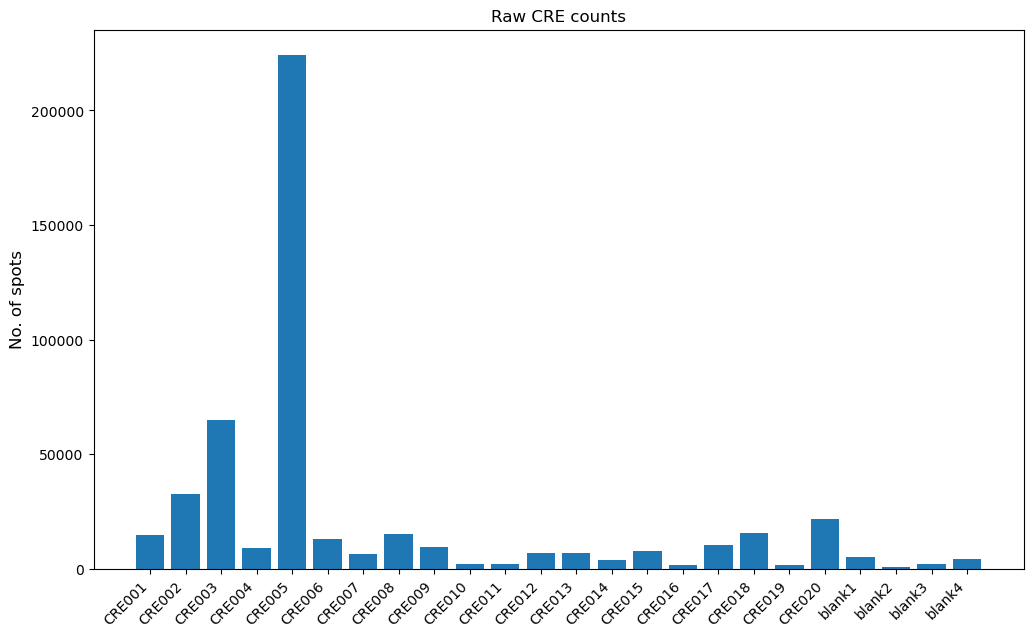

In [225]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,7))

CREs = ('CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020', 'blank1', 'blank2', 'blank3', 'blank4')

ax.bar(CREs, counts)
ax.set_xticks(CREs)
ax.set_ylabel('No. of spots', fontsize=12)
ax.set_title('Raw CRE counts')
plt.xticks(rotation=45, fontsize=10, ha='right')

plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/total_CRE_counts_raw.png', dpi=450)

In [227]:
mask_counts = (12741, 26795, 55882,8093,207988,10805,5589,13407,7942,1775,1199,5408,6125,2821,6159,1403,8724,13450,1137,18710,3865,665,1206,3400)

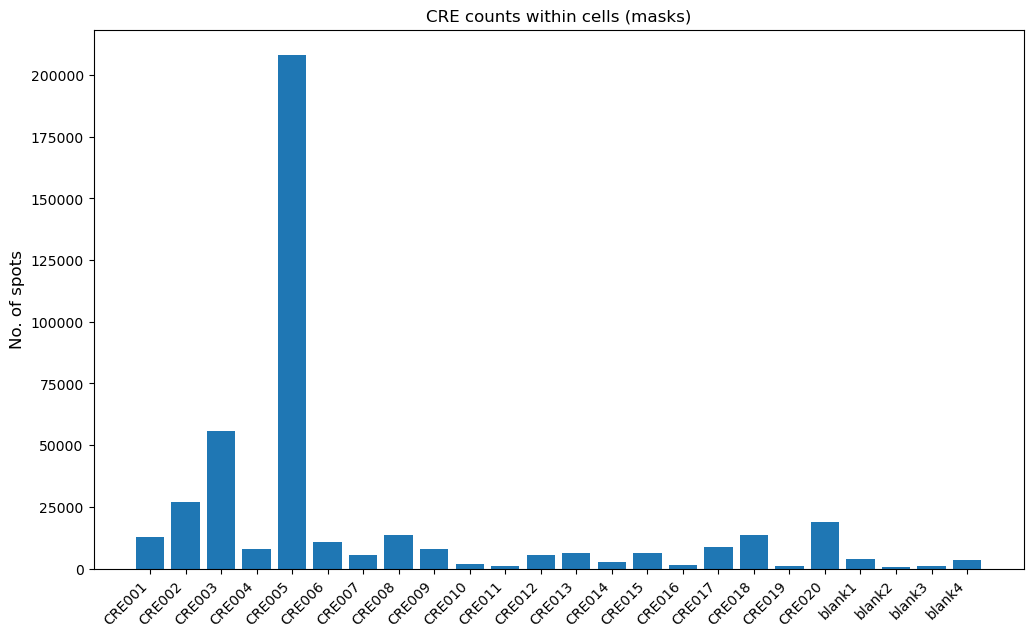

In [230]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,7))

CREs = ('CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020', 'blank1', 'blank2', 'blank3', 'blank4')

ax.bar(CREs, mask_counts)
ax.set_xticks(CREs)
ax.set_ylabel('No. of spots', fontsize=12)
plt.xticks(rotation=45, fontsize=10, ha='right')
ax.set_title('CRE counts within cells (masks)')

plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/total_CRE_counts_in_masks.png', dpi=450)

In [231]:
norm_counts = (0.010798258,0.040018304,0.082519443,0.005759427,0.738235282,0.017314582,0.003689372,0.010469746,0.009303776,0.001687861,0.002664918,0.00746725,0.004190885,0.003484805,0.007596823,0.001354234,0.006881171,0.012287095,0.001331613,0.017688851,0.005668731,0.001133136,0.003027391,0.005427047)

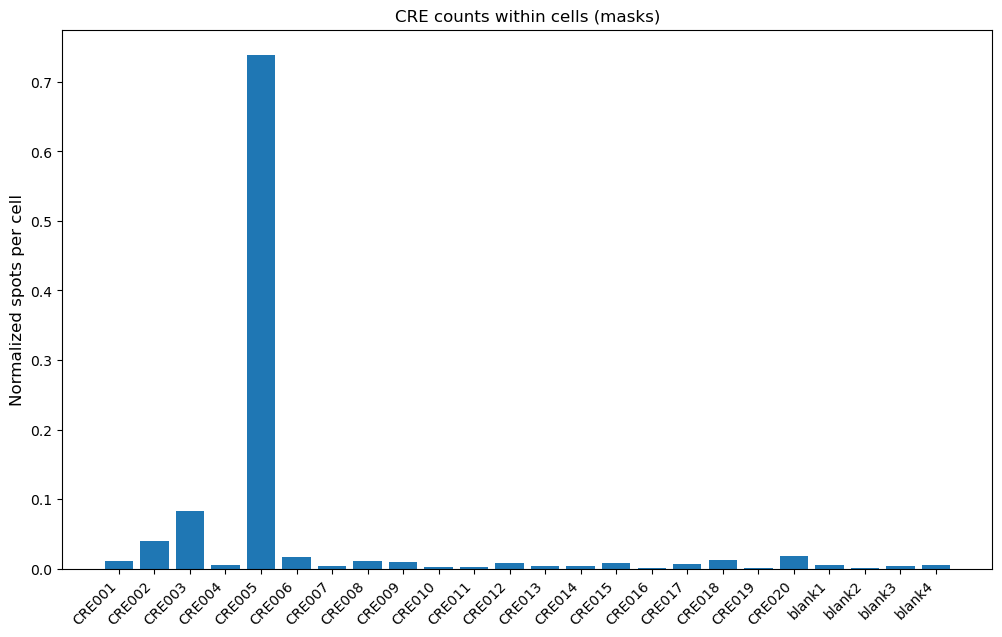

In [233]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,7))

CREs = ('CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020', 'blank1', 'blank2', 'blank3', 'blank4')

ax.bar(CREs, norm_counts)
ax.set_xticks(CREs)
ax.set_ylabel('Normalized spots per cell', fontsize=12)
plt.xticks(rotation=45, fontsize=10, ha='right')
ax.set_title('CRE counts within cells (masks)')

plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/figures/norm_CRE_counts_in_masks.png', dpi=450)